<a href="https://colab.research.google.com/github/Nutchayapon/Super_AI_Engineer-SS.6/blob/main/Mini_Hackathon1_601661.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mini-Hackathon : Data Storytelling Notebook**

จัดทำโดย

รหัส: 601661

ชื่อ-นามสกุล: ณัชยภรณ์ คันธรส

---
## Data
> ชุดข้อมูล: การเดินทางของประชาชนด้วยระบบขนส่งสาธารณะ ปี พ.ศ.2568 เเละ 2569

>Public Transportation Passenger Statistics in Thailand in 2025 and 2026

> ชุดข้อมูลใน THackle: [ข้อมูลการเดินทางของประชาชนด้วยระบบขนส่งสาธารณะ ](https://www.thackle.or.th/th/dataset/94)


## Overview of Notebook
1. Setup & Load Data
2. Data Preprocessing
    - 2.1 Changing Data Types
        - Quantitative (int/float)
        - Qualitative (category/string)
        - Date (datetime)
    - 2.2 Data Cleaning
        - Duplicates (ลบข้อมูลซ้ำ)
        - Typos / Inconsistent Values (จัดการตัวอักษรที่พิมพ์ผิด)
    - 2.3 Handling Missing Values
        - Quantitative
        - Qualitative
        - Date
    - 2.4 Date Enrichment
3. Exploratory Data Analysis (EDA): Key Insights & Challenges
    - 3.1 Comparative Analysis: Passenger Performance
        -  Passenger 2025 (Jan-Dec)
        -  Snapshot: Passenger 2025 (Jan-Mar)
        -  Snapshot: Passenger 2026 (Jan-Mar)
        -  Summary Snapshot 3 Month
    - 3.2 Deep Trend: High-Volume Segments (15 Month)
        -  Monthly Trend
            - Segment by Vehicle/Station
        -  Daily Trend
        -  Summary Deep Trend 15 Month
    - 3.3 Event Detection
        -  Daily Trend

# P.S.
> เนื้อหาจำพวก Take note, Summary note หรือ Idea ถ้าหากมีข้อผิดพลาดต้องขออภัย ซึ่งสามารถเสนอความคิดเห็นได้เสมอ
ขอบคุณค่ะ

## 1.Setup & Load Data
> ติดตั้ง Library ที่จำเป็นและโหลดชุดข้อมูลที่จะใช้

### Import Libraries

In [ ]:
###################### Setup ######################

#Import Library ที่จำเป็น
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#ดาวน์โหลดฟอนต์ภาษาไทย (TH Sarabun New)
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font',family = 'TH Sarabun New',size = 16)
sns.set_theme(style = "whitegrid",font = "TH Sarabun New")

### Load Dataset and Inspect

In [ ]:
###################### Load Data ######################

 #เนื่องจากไฟล์ข้อมูลที่ใช้มี 2 files เลยคิดว่าเขียน loop เรียก data files (สำรองเผื่อได้เรียกไฟล์มากกว่า 2)
 # กำหนดข้อมูลไฟล์และชื่อปีที่ต้องการแสดง
data_files = {
    '2568': 'passengers68.csv',
    '2569': 'passengers69.csv'
}

dfs = {} #สร้าง dict ที่เก็บ df (เผื่อนำไปใช้ต่อ)

#loop
for years, file_name in data_files.items():
    dfs[years] = pd.read_csv(file_name, encoding='utf-8') # อ่านไฟล์และเก็บลงใน dict
    print("-" * 80)
    print(f'ข้อมูลการเดินทางของประชาชนด้วยระบบขนส่งสาธารณะ ปี พ.ศ.{years}')
    print("-" * 80)
    dfs[years].info()
    print("\n") # เว้นบรรทัด

--------------------------------------------------------------------------------
ข้อมูลการเดินทางของประชาชนด้วยระบบขนส่งสาธารณะ ปี พ.ศ.2568
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15696 entries, 0 to 15695
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   รูปแบบการเดินทาง   15696 non-null  object
 1   วัตถุประสงค์       15696 non-null  object
 2   สาธารณะ/ส่วนบุคคล  15696 non-null  object
 3   หน่วยงาน           15696 non-null  object
 4   ยานพาหนะ/ท่า       15696 non-null  object
 5   วันที่             15696 non-null  object
 6   หน่วย              15696 non-null  object
 7   ปริมาณ             15388 non-null  object
dtypes: object(8)
memory usage: 981.1+ KB


--------------------------------------------------------------------------------
ข้อมูลการเดินทางของประชาชนด้วยระบบขนส่งสาธารณะ ปี พ.ศ.2569
-----------------

## 2.Data Preprocessing

### Take note


---
#### Levels of Measurement(มาตรระดับการวัดตัวแปร)
---
> ในที่นี้จะยกตัวอย่างให้เห็นภาพ ถ้าอยากศึกษาเพิ่มลองค้นหาดูได้

- Nominal Scale คือ ใช้จำแนกความต่างเท่านั้น คำนวณหรือเรียงลำดับไม่ได้
- Ordinal Scale คือ บอกความมากกว่า-น้อยกว่าได้แต่ระยะห่างแต่ละขั้นไม่เท่ากัน
- Interval Scale คือ บวก/ลบกันได้ แต่ไม่มีศูนย์แท้ (0 ไม่ได้แปลว่าไม่มีเลย)
- Ratio Scale คือ มีศูนย์แท้ สามารถคำนวณแบบเปรียบเทียบ "เท่า" ได้


---
#### Data Types (ประเภทของข้อมูล) ของเเต่ละ Column
---

1. Quantitative Data (ข้อมูลเชิงปริมาณ) คือ ข้อมูลที่เป็นตัวเลข สามารถนำมาบวก ลบ คูณ หาร หรือหาค่าเฉลี่ยได้
2. Qualitative Data (ข้อมูลเชิงคุณภาพ) คือ ข้อมูลที่อธิบายลักษณะ คุณสมบัติ  ไม่สามารถนำมาคำนวณทางคณิตศาสตร์ตรงๆ ได้

### Summary note


---
#### สรุปเนื้อหาจาก Take note
---

|มาตรวัด (Scale) |ประเภทข้อมูล (Data Type) |ตัวอย่างข้อมูล|
|--------|--------|--------|
|Nominal|Qualitative|รหัสสินค้า, เพศ, รหัสไปรษณีย์|
|Ordinall|Qualitative|ระดับความพึงพอใจ, ขนาดเสื้อ (S,M,L)|
|Interval|Quantitative|อุณหภูมิ (C/F), เวลา|
|Ratio|Quantitative|รายได้, น้ำหนัก, ยอดขาย, อายุ|


---
#### สรุปประเภทของตัวเเปร
---
1. Quantitative มี 1 column
    - 1.1 ปริมาณ
2. Qualitative มี 6 column
    - 1.1 รูปแบบการเดินทาง
    - 1.2 วัตถุประสงค์
    - 1.3 สาธารณะ/ส่วนบุคคล
    - 1.4 หน่วยงาน
    - 1.5 ยานพาหนะ/ท่า
    - 1.6 หน่วย (คน/คัน)
3. Date มี 1 column
    - 1.1 วันที่

### Idea 🔖
ส่วนตัวคิดว่าจะเเยกทำตามประเภทของตัวเเปร คือ Quantitative (ข้อมูลเชิงปริมาณ) Qualitative (ข้อมูลเชิงคุณภาพ) เเละ ข้อมูลเวลา
> เพราะข้อมูลแต่ละประเภทมีการใช้สถิติที่ต่างกัน การแยกส่วนช่วยให้เราเลือกสถิติที่ใช้เหมาะสม เเละ มองภาพลำดับการจัดการได้เหมาะกว่า

> เช่น กรณี Missing values ตัว Quantitative (ข้อมูลเชิงปริมาณ) จะเลือกใช้  mean เเละ median เเต่  Qualitative (ข้อมูลเชิงคุณภาพ) จะเลือกใช้ mode

### 2.1 Changing Data Types

In [ ]:
#เช็ค colums ใน data frame 2568 เเละ 2569
print(dfs['2568'].columns)
print("--"*50)
print(dfs['2569'].columns)

Index(['รูปแบบการเดินทาง', 'วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล', 'หน่วยงาน',
       'ยานพาหนะ/ท่า', 'วันที่', 'หน่วย', 'ปริมาณ'],
      dtype='object')
----------------------------------------------------------------------------------------------------
Index(['รูปแบบการเดินทาง', 'วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล', 'หน่วยงาน',
       'ยานพาหนะ/ท่า', 'วันที่', 'หน่วย', 'ปริมาณ'],
      dtype='object')


#### Quantitative

In [ ]:
#ตัวอย่าง column ปริมาณ ใน 2568
dfs['2568']['ปริมาณ']

,ปริมาณ
0,"127,551"
1,"8,218"
2,"877,943"
3,"932,642"
4,"1,364,992"
...,...
15691,"19,497"
15692,"24,698"
15693,"22,231"
15694,"1,351"


In [ ]:
# เขียน loop เพื่อแปลงปริมาณเป็นเลข (int64)
for year in dfs:
    # 1. ลบเครื่องหมายคอมมา(,) ออกก่อน (เช่น "1,200" -> "1200")
    dfs[year]['ปริมาณ'] = dfs[year]['ปริมาณ'].astype(str).str.replace(',', '')

    # 2. แปลงเป็นตัวเลข
    dfs[year]['ปริมาณ'] = pd.to_numeric(dfs[year]['ปริมาณ'], errors='coerce').astype('Int64')

In [ ]:
# เช็คดูตัวอย่าง column ปริมาณ ใน 2568 เเละ 2569
for year in dfs:
  print(f"ข้อมูลปี {year}")
  print(dfs[year]['ปริมาณ'].head(5))
  print("\n")

ข้อมูลปี 2568
0     127551
1       8218
2     877943
3     932642
4    1364992
Name: ปริมาณ, dtype: Int64


ข้อมูลปี 2569
0     112325
1          0
2     892218
3     980649
4    1231605
Name: ปริมาณ, dtype: Int64




In [ ]:
# ลองเช็ก type ดูว่าเปลี่ยนไหม
print(dfs['2568']['ปริมาณ'].dtype)
print(dfs['2569']['ปริมาณ'].dtype)

Int64
Int64


#### Qualitative

In [ ]:
## ดูจาก dfs[years].info() จะเห็นว่าอีก 6 columns เป็น str เเล้ว

In [ ]:
### ลอง loop เช็กดูอีกรอบก็ได้ (เช็กทุก cloumns นะ)
for year, df in dfs.items():
    print("-" * 40)
    print(f"Data Types ของปี พ.ศ. {year}:")
    print("-" * 40)
    print(df.dtypes)
    print("\n")

----------------------------------------
Data Types ของปี พ.ศ. 2568:
----------------------------------------
รูปแบบการเดินทาง     object
วัตถุประสงค์         object
สาธารณะ/ส่วนบุคคล    object
หน่วยงาน             object
ยานพาหนะ/ท่า         object
วันที่               object
หน่วย                object
ปริมาณ                Int64
dtype: object


----------------------------------------
Data Types ของปี พ.ศ. 2569:
----------------------------------------
รูปแบบการเดินทาง     object
วัตถุประสงค์         object
สาธารณะ/ส่วนบุคคล    object
หน่วยงาน             object
ยานพาหนะ/ท่า         object
วันที่               object
หน่วย                object
ปริมาณ                Int64
dtype: object




#### Date

In [ ]:
# สร้าง Function ที่เปลี่ยน column 'วันที่' เป็น Datetime
# CE (ค.ศ.)
def convert_ce_to_dt(df, col='วันที่'):
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')
    return df

for year in dfs:
    dfs[year] = convert_ce_to_dt(dfs[year])

In [ ]:
print(dfs['2568']['วันที่'].head())
print("-" * 40)
print(dfs['2569']['วันที่'].head())

0   2025-01-01
1   2025-01-01
2   2025-01-01
3   2025-01-01
4   2025-01-01
Name: วันที่, dtype: datetime64[ns]
----------------------------------------
0   2026-01-01
1   2026-01-01
2   2026-01-01
3   2026-01-01
4   2026-01-01
Name: วันที่, dtype: datetime64[ns]


#### Summary Data Type
> ดูประเภทของเเต่ละตัวเเปร (columns)

In [ ]:
# deepcopy for some mistake
df_2568 = dfs['2568'].copy(deep=True)
df_2569 = dfs['2569'].copy(deep=True)

In [ ]:
df_2568.dtypes

,0
รูปแบบการเดินทาง,object
วัตถุประสงค์,object
สาธารณะ/ส่วนบุคคล,object
หน่วยงาน,object
ยานพาหนะ/ท่า,object
วันที่,datetime64[ns]
หน่วย,object
ปริมาณ,Int64


In [ ]:
df_2568.dtypes

,0
รูปแบบการเดินทาง,object
วัตถุประสงค์,object
สาธารณะ/ส่วนบุคคล,object
หน่วยงาน,object
ยานพาหนะ/ท่า,object
วันที่,datetime64[ns]
หน่วย,object
ปริมาณ,Int64


### 2.2 Data Cleaning

In [ ]:
df_2568.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15696 entries, 0 to 15695
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   รูปแบบการเดินทาง   15696 non-null  object        
 1   วัตถุประสงค์       15696 non-null  object        
 2   สาธารณะ/ส่วนบุคคล  15696 non-null  object        
 3   หน่วยงาน           15696 non-null  object        
 4   ยานพาหนะ/ท่า       15696 non-null  object        
 5   วันที่             15696 non-null  datetime64[ns]
 6   หน่วย              15696 non-null  object        
 7   ปริมาณ             15388 non-null  Int64         
dtypes: Int64(1), datetime64[ns](1), object(6)
memory usage: 996.5+ KB


In [ ]:
df_2569.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   รูปแบบการเดินทาง   3010 non-null   object        
 1   วัตถุประสงค์       3010 non-null   object        
 2   สาธารณะ/ส่วนบุคคล  3010 non-null   object        
 3   หน่วยงาน           3010 non-null   object        
 4   ยานพาหนะ/ท่า       3010 non-null   object        
 5   วันที่             3010 non-null   datetime64[ns]
 6   หน่วย              3010 non-null   object        
 7   ปริมาณ             2874 non-null   Int64         
dtypes: Int64(1), datetime64[ns](1), object(6)
memory usage: 191.2+ KB


#### Duplicates
> ลบข้อมูลซ้ำ

In [ ]:
df_2568

,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,2025-01-01,คน,127551
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,2025-01-01,คน,8218
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),2025-01-01,คัน,877943
3,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์ทุกประเภท (10 จุดสำรวจ),2025-01-01,คัน,932642
4,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,กทพ.,รถยนต์เฉพาะ 4 ล้อ (ทางด่วน),2025-01-01,คัน,1364992
...,...,...,...,...,...,...,...,...
15691,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานดอนเมือง ขาออกประเทศ,2025-12-31,คน,19497
15692,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานอื่น ๆ ของ ทอท. ขาเข้าประเทศ,2025-12-31,คน,24698
15693,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานอื่น ๆ ของ ทอท. ขาออกประเทศ,2025-12-31,คน,22231
15694,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทย.,ท่าอากาศยานภูมิภาค ขาเข้าประเทศ,2025-12-31,คน,1351


In [ ]:
dfs_cleaned = {'2568': df_2568, '2569': df_2569} # เอามาใส่ dict เพื่อให้ loop อัปเดตค่าได้

for year, df in dfs_cleaned.items():
    print("-" * 70)
    print(f"ข้อมูลปี พ.ศ. {year}")
    print("-" * 70)
    print(f"จำนวนเเถวทั้งหมดตอนเเรก (Before): {len(df)} เเถว")

    # เช็คแถวซ้ำ
    duplicates = df[df.duplicated(keep=False)]
    print(f"พบแถวที่ซ้ำกันทั้งหมด: {len(duplicates)} แถว")
    # print(duplicates)

    # ลบแถวซ้ำและเซฟทับกลับเข้าไปใน dict
    dfs_cleaned[year] = df.drop_duplicates().reset_index(drop=True)

    print(f"จำนวนแถวที่เหลืออยู่ (After) : {len(dfs_cleaned[year])} เเถว")
    print("\n")

# อัปเดตกลับไปยังตัวหลัก
df_2568 = dfs_cleaned['2568']
df_2569 = dfs_cleaned['2569']

----------------------------------------------------------------------
ข้อมูลปี พ.ศ. 2568
----------------------------------------------------------------------
จำนวนเเถวทั้งหมดตอนเเรก (Before): 15696 เเถว
พบแถวที่ซ้ำกันทั้งหมด: 2 แถว
จำนวนแถวที่เหลืออยู่ (After) : 15695 เเถว


----------------------------------------------------------------------
ข้อมูลปี พ.ศ. 2569
----------------------------------------------------------------------
จำนวนเเถวทั้งหมดตอนเเรก (Before): 3010 เเถว
พบแถวที่ซ้ำกันทั้งหมด: 0 แถว
จำนวนแถวที่เหลืออยู่ (After) : 3010 เเถว




#### Typos / Inconsistent Values
> จัดการตัวอักษรที่พิมพ์ผิด

In [ ]:
################## ดู unique values ของแต่ละ column ##################

for col in df_2568.select_dtypes(include='object').columns:
    print(f"\n[df_2568] {col}:")
    print(sorted(df_2568[col].dropna().unique()))

print("-" * 150)

for col in df_2569.select_dtypes(include='object').columns:
    print(f"\n[df_2569] {col}:")
    print(sorted(df_2569[col].dropna().unique()))


[df_2568] รูปแบบการเดินทาง:
['ทางถนน', 'ทางน้ำ', 'ทางราง', 'ทางอากาศ']

[df_2568] วัตถุประสงค์:
['การเดินทางภายในจังหวัด/กรุงเทพ', 'การเดินทางระหว่างจังหวัด', 'การเดินทางระหว่างประเทศ']

[df_2568] สาธารณะ/ส่วนบุคคล:
['สาธารณะ', 'ส่วนบุคคล']

[df_2568] หน่วยงาน:
['กทพ.', 'กทม.', 'กพท.', 'ขบ.', 'ขสมก.', 'จท.', 'ทย.', 'ทล.', 'ทอท.', 'บขส.', 'รฟท.', 'รฟฟท.', 'รฟม.']

[df_2568] ยานพาหนะ/ท่า:
['ท่าอากาศยานดอนเมือง', 'ท่าอากาศยานดอนเมือง ขาออกประเทศ', 'ท่าอากาศยานดอนเมือง ขาเข้าประเทศ', 'ท่าอากาศยานภูมิภาค', 'ท่าอากาศยานภูมิภาค ขาออกประเทศ', 'ท่าอากาศยานภูมิภาค ขาเข้าประเทศ', 'ท่าอากาศยานสมุย', 'ท่าอากาศยานสุวรรณภูมิ', 'ท่าอากาศยานสุวรรณภูมิ ขาออกประเทศ', 'ท่าอากาศยานสุวรรณภูมิ ขาเข้าประเทศ', 'ท่าอากาศยานอื่น ๆ ของ ทอท. ขาออกประเทศ', 'ท่าอากาศยานอื่น ๆ ของ ทอท. ขาเข้าประเทศ', 'ท่าอากาศยานอู่ตะเภา', 'ท่าอากาศอื่น ๆ ของ ทอท.', 'ท่าเรือด่านชายแดน ขาออกประเทศ', 'ท่าเรือด่านชายแดน ขาเข้าประเทศ', 'รถ บขส. ขาออกประเทศ', 'รถ บขส. ขาเข้าประเทศ', 'รถ บขส. และ รถร่วม', 'รถยนต์ทุกประเภท (10 จุดสำรวจ)', 

In [ ]:
#จากการดูพบว่า ไม่มีตัวอักษรที่พิมพ์ผิดในทุก col ของ 2 ปี (พ.ส.2568 & 2569)

### 2.3 Handling Missing Values
> จัดการกับค่าสูญหาย

In [ ]:
df_2568.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15695 entries, 0 to 15694
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   รูปแบบการเดินทาง   15695 non-null  object        
 1   วัตถุประสงค์       15695 non-null  object        
 2   สาธารณะ/ส่วนบุคคล  15695 non-null  object        
 3   หน่วยงาน           15695 non-null  object        
 4   ยานพาหนะ/ท่า       15695 non-null  object        
 5   วันที่             15695 non-null  datetime64[ns]
 6   หน่วย              15695 non-null  object        
 7   ปริมาณ             15387 non-null  Int64         
dtypes: Int64(1), datetime64[ns](1), object(6)
memory usage: 996.4+ KB


In [ ]:
df_2569.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   รูปแบบการเดินทาง   3010 non-null   object        
 1   วัตถุประสงค์       3010 non-null   object        
 2   สาธารณะ/ส่วนบุคคล  3010 non-null   object        
 3   หน่วยงาน           3010 non-null   object        
 4   ยานพาหนะ/ท่า       3010 non-null   object        
 5   วันที่             3010 non-null   datetime64[ns]
 6   หน่วย              3010 non-null   object        
 7   ปริมาณ             2874 non-null   Int64         
dtypes: Int64(1), datetime64[ns](1), object(6)
memory usage: 191.2+ KB


#### Summary Missing Values
- ปี พ.ศ. 2568
  - Quantitative (ข้อมูลเชิงปริมาณ) มี Missing Values (mean เเละ median)
  - Qualitative (ข้อมูลเชิงคุณภาพ) ไม่มี Missing Values
  - Date (วันที่) — ไม่มี missing values

---

- ปี พ.ศ. 2569
  - Quantitative (ข้อมูลเชิงปริมาณ) มี Missing Values (mean เเละ median)
  - Qualitative (ข้อมูลเชิงคุณภาพ) ไม่มี Missing Values
  - Date (วันที่) — ไม่มี missing values


#### Take note


---
#### พิจารณาการเลือกเติมค่า mean เเละ median ใน Quantitative (ข้อมูลเชิงปริมาณ)
---
> ในที่นี้จะอธิบายสั้นๆ เราเลือกว่าจะเติมค่าอะไร จะพิจารณาจาก "distribution + outlier" (ฺBox plot)

    - ถ้ามี outlier → เลือก median
    - ถ้าไม่มี outlier → เลือก mean

#### Quantitative

In [ ]:
# Before

#2568
missing_count = df_2568['ปริมาณ'].isnull().sum()
print(f"จำนวนค่าว่างในคอลัมน์ปริมาณ ปี พ.ศ. 2568: {missing_count}")

#2569
missing_count = df_2569['ปริมาณ'].isnull().sum()
print(f"จำนวนค่าว่างในคอลัมน์ปริมาณ ปี พ.ศ. 2568: {missing_count}")

จำนวนค่าว่างในคอลัมน์ปริมาณ ปี พ.ศ. 2568: 308
จำนวนค่าว่างในคอลัมน์ปริมาณ ปี พ.ศ. 2568: 136


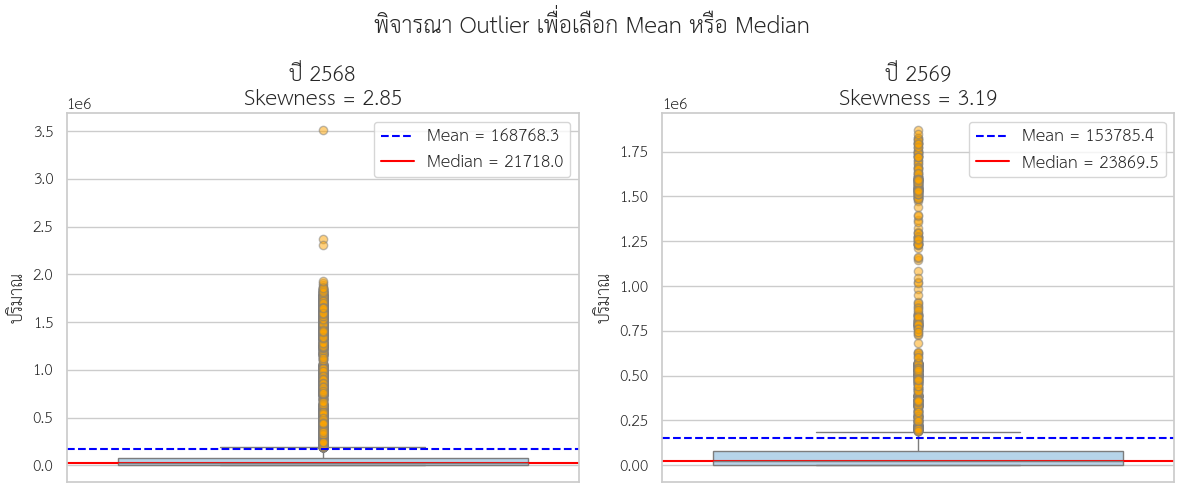

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (df, year) in zip(axes, [(df_2568, '2568'), (df_2569, '2569')]):
    sns.boxplot(y=df['ปริมาณ'].dropna(), ax=ax,
                color='#AED6F1',
                flierprops=dict(marker='o', markerfacecolor='orange', alpha=0.5))

    mean_val = df['ปริมาณ'].mean()
    median_val = df['ปริมาณ'].median()
    skew_val = df['ปริมาณ'].skew()

    ax.axhline(mean_val, color='blue', linestyle='--', linewidth=1.5, label=f'Mean = {mean_val:.1f}')
    ax.axhline(median_val, color='red', linestyle='-', linewidth=1.5, label=f'Median = {median_val:.1f}')

    ax.set_title(f'ปี {year}\nSkewness = {skew_val:.2f}', fontsize=15)
    ax.set_ylabel('ปริมาณ')
    ax.legend(fontsize=12)

plt.suptitle('พิจารณา Outlier เพื่อเลือก Mean หรือ Median', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

####  Summary  Quantitative
> ทั้ง 2 ปี (พ.ศ.2568 เเละ 2569) มีสัญญาณชัดเจนว่า 'ข้อมูลเบ้ขวา'

> ตัวอย่างของข้อมูลเบ้ขวา เช่น วันปกติอาจมีผู้โดยสาร 10,000 - 30,000 คน แต่บางวันพิเศษ (เทศกาล, วันหยุดยาว) พุ่งไปถึงหลักล้าน → ค่าเหล่านี้คือ Outlier ที่ดึงให้ Mean สูงขึ้นจนไม่สะท้อนความเป็นจริงของวันทั่วไป

ทำไมเราถึงรู้ข้อมูลเบ้ขวา เนื่องจาก
  - Skewness > 1 ทั้งคู่ (2.85 และ 3.19)
  - Outlier (จุดสีเหลือง) กระจายสูงมาก
  - ค่า Mean ห่างจาก ค่า Median เยอะมาก

ดังนั้น
- เลือกเติมค่าด้วย Median ทั้ง 2 ปี
> เพราะ Median ไม่ได้รับผลกระทบจาก Outlier

In [ ]:
# เติมด้วยค่า Median ทั้ง 2 ปี
#ต้องใช้ round เพื่อปัดเลข float เป็น int
df_2568['ปริมาณ'] = df_2568['ปริมาณ'].fillna(round(df_2568['ปริมาณ'].median())).astype('Int64')
df_2569['ปริมาณ'] = df_2569['ปริมาณ'].fillna(round(df_2569['ปริมาณ'].median())).astype('Int64')

In [ ]:
# After

#2568
missing_count = df_2568['ปริมาณ'].isnull().sum()
print(f"จำนวนค่าว่างในคอลัมน์ปริมาณ ปี พ.ศ. 2568: {missing_count}")

#2569
missing_count = df_2569['ปริมาณ'].isnull().sum()
print(f"จำนวนค่าว่างในคอลัมน์ปริมาณ ปี พ.ศ. 2568: {missing_count}")

จำนวนค่าว่างในคอลัมน์ปริมาณ ปี พ.ศ. 2568: 0
จำนวนค่าว่างในคอลัมน์ปริมาณ ปี พ.ศ. 2568: 0


### 2.4 Date Enrichment
> ดึงข้อมูลจาก col วันที่ แตกออกเป็น features ย่อย ได้แก่ ปี เดือน วัน quarter และ day_of_week

> Extract: Year, Quarter, Month, Day of week (0=Mon, 6=Sun)

In [ ]:
date_col = "วันที่"

for name, df in [("df_2568", df_2568), ("df_2569", df_2569)]:

    #############  ปี / เดือน / วัน #############
    df["year"]  = df[date_col].dt.year
    df["month"] = df[date_col].dt.month
    df["day"]   = df[date_col].dt.day

    ############# ไตรมาส (Q1-Q4) #############
    df["quarter"] = df[date_col].dt.quarter

    ############# วันในสัปดาห์ #############
    df["day_of_week"] = df[date_col].dt.day_name()  # 'Monday', 'Tuesday', ...
    df["is_weekend"]  = df[date_col].dt.dayofweek >= 5 #เช็คว่าวันเป็น "วันเสาร์ หรือ วันอาทิตย์" ไหม (จากการตัวเลขดัชนีของวันในสัปดาห์ เช่น ตัวเลขดัชนีนั้นมีค่ามากกว่า 5 เสาร์)

    print(f"\n=== {name} ===")
    print(df[["year", "month", "day", "quarter", "day_of_week", "is_weekend"]].head())


=== df_2568 ===
   year  month  day  quarter day_of_week  is_weekend
0  2025      1    1        1   Wednesday       False
1  2025      1    1        1   Wednesday       False
2  2025      1    1        1   Wednesday       False
3  2025      1    1        1   Wednesday       False
4  2025      1    1        1   Wednesday       False

=== df_2569 ===
   year  month  day  quarter day_of_week  is_weekend
0  2026      1    1        1    Thursday       False
1  2026      1    1        1    Thursday       False
2  2026      1    1        1    Thursday       False
3  2026      1    1        1    Thursday       False
4  2026      1    1        1    Thursday       False


In [ ]:
########### ปี พ.ศ. 2568 ###########
df_2568.info() #ใช้ .info() มาเช็คดุว่ามี col เพิ่มไหม
# จะพบว่ามี col เพิ่มเข้ามาจากการที่เราทำ Date Enrichment
print('--'*50)

########### ปี พ.ศ. 2569 ###########
df_2569.info() #ใช้ .info() มาเช็คดุว่ามี col เพิ่มไหม
# จะพบว่ามี col เพิ่มเข้ามาจากการที่เราทำ Date Enrichment

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15695 entries, 0 to 15694
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   รูปแบบการเดินทาง   15695 non-null  object        
 1   วัตถุประสงค์       15695 non-null  object        
 2   สาธารณะ/ส่วนบุคคล  15695 non-null  object        
 3   หน่วยงาน           15695 non-null  object        
 4   ยานพาหนะ/ท่า       15695 non-null  object        
 5   วันที่             15695 non-null  datetime64[ns]
 6   หน่วย              15695 non-null  object        
 7   ปริมาณ             15695 non-null  Int64         
 8   year               15695 non-null  int32         
 9   month              15695 non-null  int32         
 10  day                15695 non-null  int32         
 11  quarter            15695 non-null  int32         
 12  day_of_week        15695 non-null  object        
 13  is_weekend         15695 non-null  bool          
dtypes: Int

##### Recheck: day_of_week and is_weekend

In [ ]:
########### ปี พ.ศ. 2568 ###########
# สร้างคอลัมน์เป็นตัวเลข (0=Mon, 6=Sun) เผื่อใช้เวลาเราจะดูเรียง sort
df_2568['day_num'] = df_2568[date_col].dt.dayofweek
# แล้วค่อยสั่งนับโดยใช้ day_num
print(df_2568[['day_num', 'day_of_week', 'is_weekend']].value_counts().sort_index())

print('--'*30)

########### ปี พ.ศ. 2569 ###########
df_2569['day_num'] = df_2569[date_col].dt.dayofweek
print(df_2569[['day_num', 'day_of_week', 'is_weekend']].value_counts().sort_index())

day_num  day_of_week  is_weekend
0        Monday       False         2236
1        Tuesday      False         2236
2        Wednesday    False         2279
3        Thursday     False         2236
4        Friday       False         2236
5        Saturday     True          2236
6        Sunday       True          2236
Name: count, dtype: int64
------------------------------------------------------------
day_num  day_of_week  is_weekend
0        Monday       False         430
1        Tuesday      False         430
2        Wednesday    False         430
3        Thursday     False         430
4        Friday       False         430
5        Saturday     True          430
6        Sunday       True          430
Name: count, dtype: int64


##### Recheck: Quarter

In [ ]:
df_2568['quarter'].value_counts().sort_index()

,count
quarter,
1,3870
2,3913
3,3956
4,3956


## 3.Exploratory Data Analysis (EDA): Challenges

#### Recap

In [ ]:
########### ปี พ.ศ. 2568 ###########
df_2568.info()
print('--'*50)

########### ปี พ.ศ. 2569 ###########
df_2569.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15695 entries, 0 to 15694
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   รูปแบบการเดินทาง   15695 non-null  object        
 1   วัตถุประสงค์       15695 non-null  object        
 2   สาธารณะ/ส่วนบุคคล  15695 non-null  object        
 3   หน่วยงาน           15695 non-null  object        
 4   ยานพาหนะ/ท่า       15695 non-null  object        
 5   วันที่             15695 non-null  datetime64[ns]
 6   หน่วย              15695 non-null  object        
 7   ปริมาณ             15695 non-null  Int64         
 8   year               15695 non-null  int32         
 9   month              15695 non-null  int32         
 10  day                15695 non-null  int32         
 11  quarter            15695 non-null  int32         
 12  day_of_week        15695 non-null  object        
 13  is_weekend         15695 non-null  bool          
 14  day_nu

#### Add on New data frame

In [ ]:
########### ปี พ.ศ. 2568 ###########
df_2568_y = df_2568.copy(deep=True)
########### ปี พ.ศ. 2569 ###########
df_2569_y = df_2569.copy(deep=True)

########### ปี พ.ศ. 2568 เเละ 2569 ###########
# รวม df_2568_y เเละ df_2569_y

# 1. เพิ่ม col  'ปี'
df_2568_y['ปี'] = 2568
df_2569_y['ปี'] = 2569

# 2. รวม DataFrameเข้าด้วยกัน
df_combined = pd.concat([df_2568_y, df_2569_y], ignore_index=True)

In [ ]:
df_2568_y.columns

Index(['รูปแบบการเดินทาง', 'วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล', 'หน่วยงาน',
       'ยานพาหนะ/ท่า', 'วันที่', 'หน่วย', 'ปริมาณ', 'year', 'month', 'day',
       'quarter', 'day_of_week', 'is_weekend', 'day_num', 'ปี'],
      dtype='object')

In [ ]:
df_combined.columns

Index(['รูปแบบการเดินทาง', 'วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล', 'หน่วยงาน',
       'ยานพาหนะ/ท่า', 'วันที่', 'หน่วย', 'ปริมาณ', 'year', 'month', 'day',
       'quarter', 'day_of_week', 'is_weekend', 'day_num', 'ปี'],
      dtype='object')

#### Idea 🔖
> การใช้หน่วยเป็น (หน่วย:คน) จะเเสดงถึงปริมาณผู้โดยสารได้

> ดังนั้น จึงพิจารณาใช้ หน่วย:คน

##### Passengers
> ปริมาณผู้โดยสาร (หน่วย:คน)

In [ ]:
##################### ปริมาณผู้โดยสาร (หน่วย:คน) #####################
## --------------- ข้อมูลปริมาณผู้โดยสารรวม ประจำปี พ.ศ. 2568 ---------------

df_people_68 = df_2568_y[df_2568_y['หน่วย'] == 'คน']
total_people_68 = df_people_68['ปริมาณ'].sum()
print(f"ปริมาณผู้โดยสารรวมทั้งปี พ.ศ. 2568 : {total_people_68:,} คน")

ปริมาณผู้โดยสารรวมทั้งปี พ.ศ. 2568 : 1,074,315,723 คน


In [ ]:
##################### ปริมาณผู้โดยสาร (หน่วย:คน) #####################
## --------------- ข้อมูลปริมาณผู้โดยสารรวม ประจำปี พ.ศ. 2569 ---------------

df_people_69 = df_2569_y[df_2569_y['หน่วย'] == 'คน']
total_people_69 = df_people_69['ปริมาณ'].sum()
print(f"ปริมาณผู้โดยสารรวมทั้งปี พ.ศ. 2569 (สะสมเดือนมกราคม – มีนาคม) : {total_people_69:,} คน")

ปริมาณผู้โดยสารรวมทั้งปี พ.ศ. 2569 (สะสมเดือนมกราคม – มีนาคม) : 215,911,577 คน


In [ ]:
##################### ปริมาณผู้โดยสาร (หน่วย:คน) #####################
## --------------- ข้อมูลปริมาณผู้โดยสารรวม 15 เดือน (ม.ค. 2568 – มี.ค. 2569) -----------------

df_people_c= df_combined[df_combined['หน่วย'] == 'คน']
total_people_c = df_people_c['ปริมาณ'].sum()
print(f"ปริมาณผู้โดยสารรวม 15 เดือน (ม.ค. 2568 – มี.ค. 2569) : {total_people_c:,} คน")

ปริมาณผู้โดยสารรวม 15 เดือน (ม.ค. 2568 – มี.ค. 2569) : 1,290,227,300 คน


#### 3.1 Comparative Analysis: Passenger Performance

##### Passenger 2025 (Jan-Dec)
> ภาพรวมของผู้โดยสารรวมตลอดทั้งปี พ.ศ. 2568

In [ ]:
print(f"ปริมาณผู้โดยสารรวมทั้งปี พ.ศ. 2568 : {total_people_68:,} คน")

ปริมาณผู้โดยสารรวมทั้งปี พ.ศ. 2568 : 1,074,315,723 คน


###### Purpose
> วัตถุประสงค์ของการเดินทาง

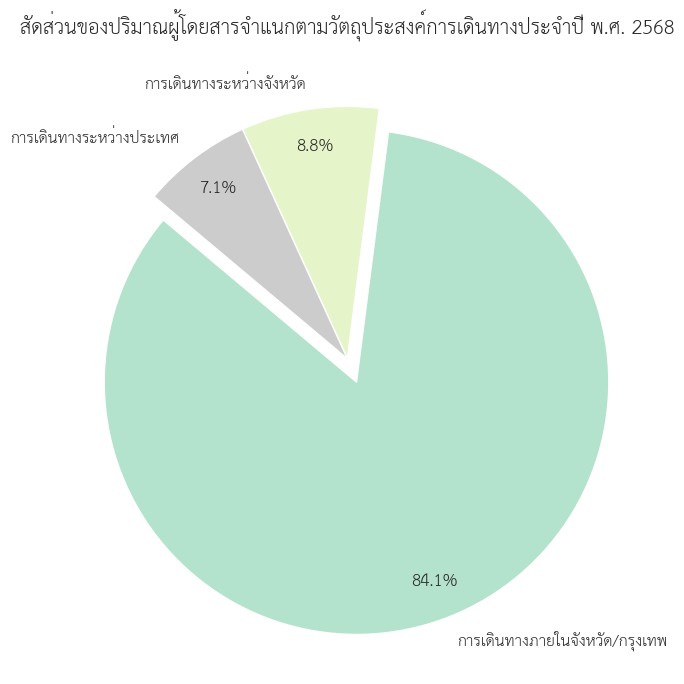

In [ ]:
# --- Purpose ( วัตถุประสงค์ของการเดินทาง) ---

# ตั้งค่าให้ Pandas แสดงคอมม่าสำหรับตัวเลขจำนวนเต็ม (Global Setting)
pd.options.display.float_format = '{:,.0f}'.format

# 1. คำนวณผลรวมของปริมาณแยกตามวัตถุประสงค์
purpose_sum_68 = df_people_68.groupby('วัตถุประสงค์')['ปริมาณ'].sum().sort_values(ascending=False).to_frame(name='ปริมาณผู้โดยสารทั้งหมด (คน)')

# 2. Pie Chart
plt.figure(figsize=(10, 7))
purpose_sum_68['ปริมาณผู้โดยสารทั้งหมด (คน)'].plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    cmap='Pastel2',
    pctdistance=0.85,
    explode=[0.1 if i == 0 else 0 for i in range(len(purpose_sum_68))]
)

plt.title('สัดส่วนของปริมาณผู้โดยสารจำแนกตามวัตถุประสงค์การเดินทางประจำปี พ.ศ. 2568', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

###### Mode
> รูปแบบการเดินทาง



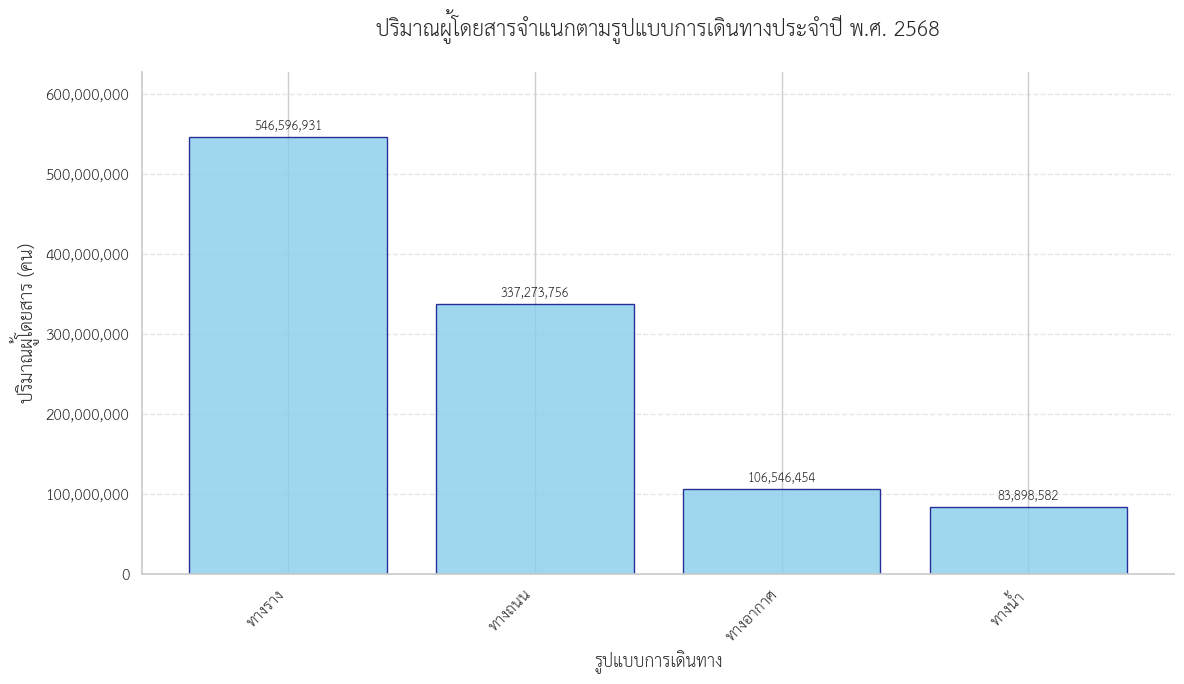

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
ตารางสรุปปริมาณผู้โดยสารจำแนกตามรูปแบบการเดินทางประจำปี พ.ศ. 2568 


,ปริมาณผู้โดยสารทั้งหมด (คน)
รูปแบบการเดินทาง,
ทางราง,"546,596,931"
ทางถนน,"337,273,756"
ทางอากาศ,"106,546,454"
ทางน้ำ,"83,898,582"


In [ ]:
# --- Mode (รูปแบบการเดินทาง) ---

# ตั้งค่าให้ Pandas แสดงคอมม่าสำหรับตัวเลขจำนวนเต็ม (Global Setting)
pd.options.display.float_format = '{:,.0f}'.format

# 1. คำนวณผลรวม (จัดเรียงจากมากไปน้อย)
mode_sum_68 = df_people_68.groupby('รูปแบบการเดินทาง')['ปริมาณ'].sum().sort_values(ascending=False).to_frame(name='ปริมาณผู้โดยสารทั้งหมด (คน)')

# 2. Bar Chart
plt.figure(figsize=(12, 7))
bars = plt.bar(mode_sum_68.index, mode_sum_68['ปริมาณผู้โดยสารทั้งหมด (คน)'],
               color='skyblue',
               edgecolor='navy',
               alpha=0.8)

# เพิ่มตัวเลขกำกับบนแต่ละแท่ง (Data Labels - แสดงหน่วยคนพร้อมคอมม่า)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (mode_sum_68['ปริมาณผู้โดยสารทั้งหมด (คน)'].max() * 0.01),
             f'{yval:,.0f}',
             ha='center',
             va='bottom',
             fontsize=9,
             fontweight='bold')

# --- ตั้งค่าแกน Y ให้แสดงเลขเต็มพร้อมคอมม่า (ป้องกัน 1e8) ---
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('ปริมาณผู้โดยสารจำแนกตามรูปแบบการเดินทางประจำปี พ.ศ. 2568', fontsize=15, pad=25, fontweight='bold')
plt.xlabel('รูปแบบการเดินทาง', fontsize=12)
plt.ylabel('ปริมาณผู้โดยสาร (คน)', fontsize=13, fontweight='bold')

# หมุนชื่อแกน X และปรับ Grid
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# ลบเส้นขอบด้านบนและด้านขวาเพื่อให้กราฟดูสะอาดขึ้น
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# เผื่อพื้นที่ด้านบนให้ตัวเลข Data Label
plt.ylim(0, mode_sum_68['ปริมาณผู้โดยสารทั้งหมด (คน)'].max() * 1.15)

plt.tight_layout()
plt.show()

# 3. แสดงตารางประกอบ
print("-" * 300)
print("ตารางสรุปปริมาณผู้โดยสารจำแนกตามรูปแบบการเดินทางประจำปี พ.ศ. 2568 ")
display(mode_sum_68.style.format("{:,.0f}"))

###### Vehicle/Station
> ยานพาหนะ/ท่า

- Top 10 Vehicles/Station by Passenger

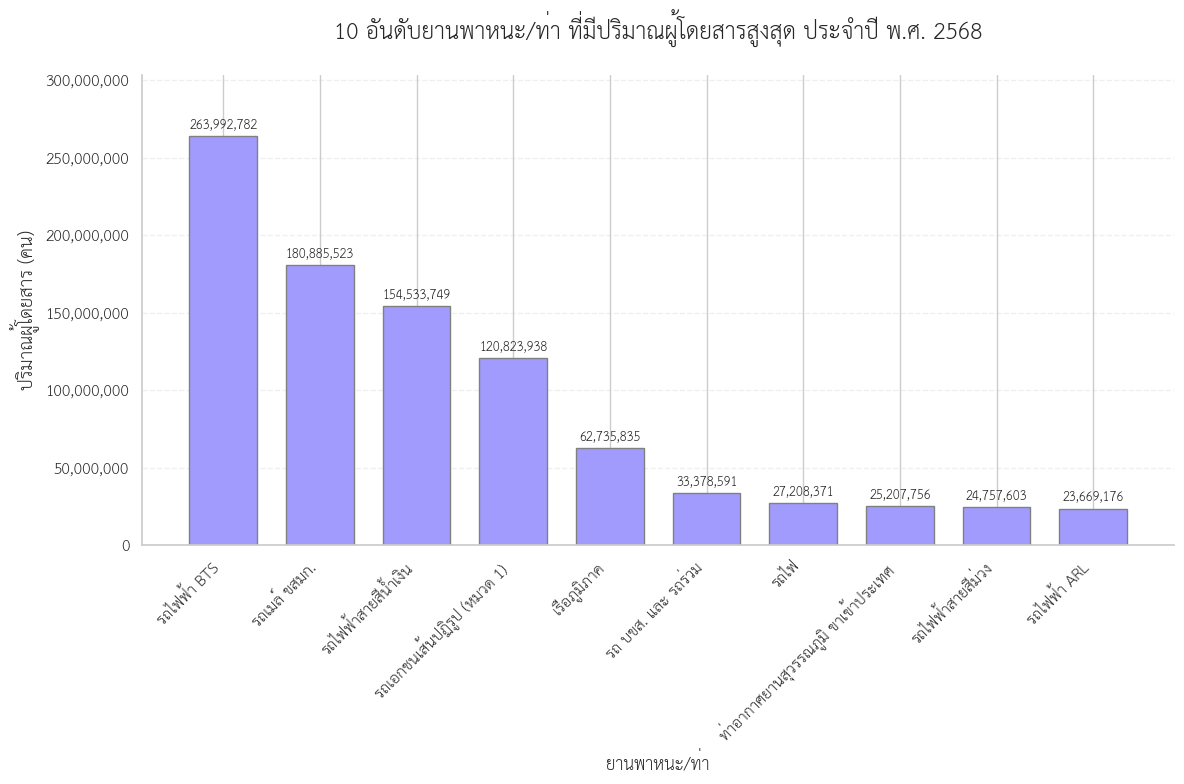

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
ตารางสรุป 10 อันดับยานพาหนะ/ท่า ที่มีปริมาณผู้โดยสารสูงสุด ประจำปี พ.ศ. 2568


,ปริมาณผู้โดยสารทั้งหมด (คน)
ยานพาหนะ/ท่า,
รถไฟฟ้า BTS,"263,992,782"
รถเมล์ ขสมก.,"180,885,523"
รถไฟฟ้าสายสีน้ำเงิน,"154,533,749"
รถเอกชนเส้นปฏิรูป (หมวด 1),"120,823,938"
เรือภูมิภาค,"62,735,835"
รถ บขส. และ รถร่วม,"33,378,591"
รถไฟ,"27,208,371"
ท่าอากาศยานสุวรรณภูมิ ขาเข้าประเทศ,"25,207,756"
รถไฟฟ้าสายสีม่วง,"24,757,603"


In [ ]:
# --- Vehicle/Station (ยานพาหนะ/ท่า ที่เกี่ยวข้องกับการเดินทาง) ---

# ตั้งค่าให้ Pandas แสดงคอมม่าสำหรับตัวเลขจำนวนเต็ม (Global Setting)
pd.options.display.float_format = '{:,.0f}'.format

# 1. คำนวณผลรวม (จัดเรียงจากมากไปน้อย)
vs_sum_68 = df_people_68.groupby('ยานพาหนะ/ท่า')['ปริมาณ'].sum().sort_values(ascending=False).head(10).to_frame(name='ปริมาณผู้โดยสารทั้งหมด (คน)')

# 2. Bar chart (หน่วย: คน)
plt.figure(figsize=(12, 8))

bars = plt.bar(vs_sum_68.index, vs_sum_68 ['ปริมาณผู้โดยสารทั้งหมด (คน)'],
               color='#A29BFE',
               edgecolor='grey',
               width=0.7)

# เพิ่ม Data Labels บนแท่ง (หน่วยคน พร้อมคอมม่า)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (vs_sum_68 ['ปริมาณผู้โดยสารทั้งหมด (คน)'].max() * 0.01),
             f'{yval:,.0f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# ปรับการตั้งค่าแกน Y ให้แสดงเลขเต็มพร้อมคอมม่า (ป้องกัน 1e8)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('10 อันดับยานพาหนะ/ท่า ที่มีปริมาณผู้โดยสารสูงสุด ประจำปี พ.ศ. 2568', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('ยานพาหนะ/ท่า', fontsize=12)
plt.ylabel('ปริมาณผู้โดยสาร (คน)', fontsize=13, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# เผื่อพื้นที่ด้านบนให้ Data Label
plt.ylim(0, vs_sum_68['ปริมาณผู้โดยสารทั้งหมด (คน)'].max() * 1.15)

plt.tight_layout()
plt.show()

# 3. แสดงตารางประกอบ
print("-" * 300)
print("ตารางสรุป 10 อันดับยานพาหนะ/ท่า ที่มีปริมาณผู้โดยสารสูงสุด ประจำปี พ.ศ. 2568")
display(vs_sum_68.style.format("{:,.0f}"))

- 4 Major Rail Systems

##### Snapshot: Passenger 2025 (Jan-Mar)
> เจาะลึก ปริมาณผู้โดยสารสะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2568

In [ ]:
df_pp_68 = df_people_68.copy(deep='TRUE')

In [ ]:
# เงื่อนไขที่ 2: ดึงช่วงเวลาที่เท่ากัน
df_2568_time = df_pp_68[(df_pp_68['วันที่'] >= '2025-01-01') & (df_pp_68['วันที่'] <= '2025-03-11')]

# เงื่อนไขที่ 1: ทำให้จำนวน Row เท่ากัน (เอาตัวที่น้อยกว่าเป็นเกณฑ์)
min_rows = min(len(df_2568_time), len(df_people_69))

df_2568_3m = df_2568_time.head(min_rows)

print(f"Final Comparison: {len(df_2568_3m)} vs {len(df_people_69)} rows")

Final Comparison: 2730 vs 2730 rows


In [ ]:
df_2568_3m['วันที่']

,วันที่
0,2025-01-01
1,2025-01-01
6,2025-01-01
7,2025-01-01
8,2025-01-01
...,...
3005,2025-03-11
3006,2025-03-11
3007,2025-03-11
3008,2025-03-11


In [ ]:
df_people_69['วันที่']

,วันที่
0,2026-01-01
1,2026-01-01
6,2026-01-01
7,2026-01-01
8,2026-01-01
...,...
3005,2026-03-11
3006,2026-03-11
3007,2026-03-11
3008,2026-03-11


In [ ]:
##################### ปริมาณผู้โดยสาร (หน่วย:คน) #####################
## --------------- ปริมาณผู้โดยสารสะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2568 ---------------

total_people_68_3m = df_2568_3m['ปริมาณ'].sum()
print(f"ปริมาณผู้โดยสารสะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2568 : {total_people_68_3m:,} คน")

ปริมาณผู้โดยสารสะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2568 : 224,072,745 คน


In [ ]:
#### hint ####
# ปริมาณผู้โดยสารสะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2568 ไม่เท่ากับ ปริมาณผู้โดยสารสะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2569
# ก็สมเหตุสมผลเพราะบางปีอาจะมียอดผู้โดยสารเยอะ บางปีมียอดผู้โดยสารน้อย

# ในทีนี้เราจะเปรีบเทียบก็สามารถทำได้ เพราะ กำหนดขอบเขตเวลา (Scope) ชัดเจน

###### Purpose
> วัตถุประสงค์ของการเดินทาง

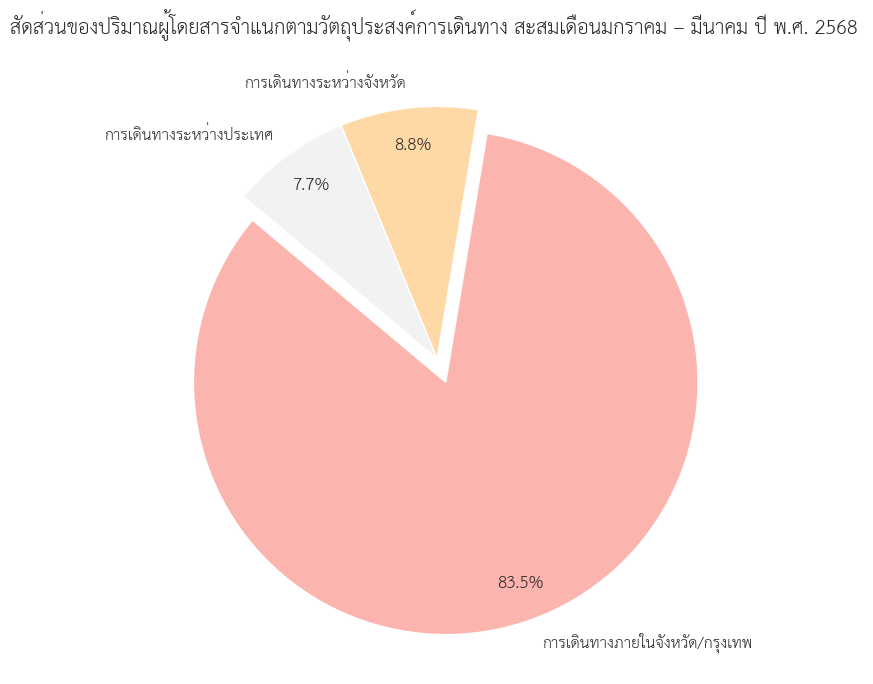

In [ ]:
# --- Purpose ( วัตถุประสงค์ของการเดินทาง) ---

# ตั้งค่าให้ Pandas แสดงคอมม่าสำหรับตัวเลขจำนวนเต็ม (Global Setting)
pd.options.display.float_format = '{:,.0f}'.format

# 1. คำนวณผลรวมของปริมาณแยกตามวัตถุประสงค์
purpose_sum_68_3m = df_2568_3m.groupby('วัตถุประสงค์')['ปริมาณ'].sum().sort_values(ascending=False).to_frame(name='ปริมาณผู้โดยสารทั้งหมด (คน)')

# 2. Pie Chart
plt.figure(figsize=(10, 7))
purpose_sum_68_3m['ปริมาณผู้โดยสารทั้งหมด (คน)'].plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    cmap='Pastel1',
    pctdistance=0.85,
    explode=[0.1 if i == 0 else 0 for i in range(len(purpose_sum_68_3m))]
)

plt.title('สัดส่วนของปริมาณผู้โดยสารจำแนกตามวัตถุประสงค์การเดินทาง สะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2568 ', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

###### Mode
> รูปแบบการเดินทาง



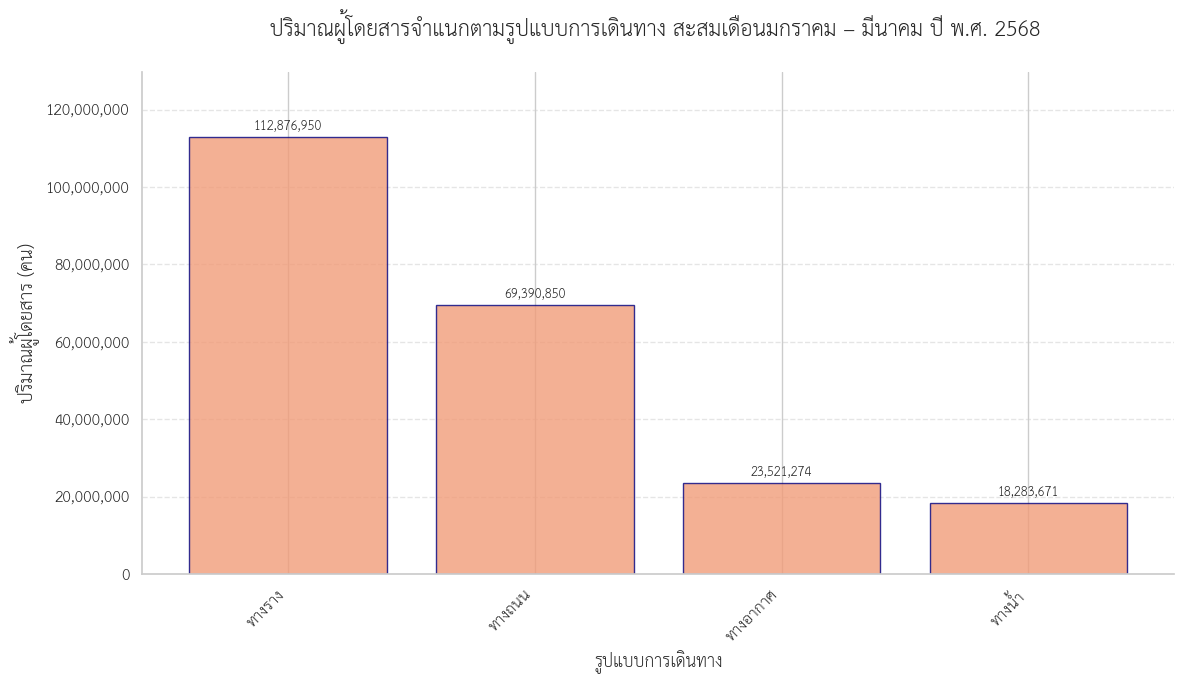

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
ตารางสรุปปริมาณผู้โดยสารจำแนกตามรูปแบบการเดินทาง สะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2568


,ปริมาณผู้โดยสารทั้งหมด (คน)
รูปแบบการเดินทาง,
ทางราง,"112,876,950"
ทางถนน,"69,390,850"
ทางอากาศ,"23,521,274"
ทางน้ำ,"18,283,671"


In [ ]:
# --- Mode (รูปแบบการเดินทาง) ---

# ตั้งค่าให้ Pandas แสดงคอมม่าสำหรับตัวเลขจำนวนเต็ม (Global Setting)
pd.options.display.float_format = '{:,.0f}'.format

# 1. คำนวณผลรวม (จัดเรียงจากมากไปน้อย)
mode_sum_68_3m = df_2568_3m.groupby('รูปแบบการเดินทาง')['ปริมาณ'].sum().sort_values(ascending=False).to_frame(name='ปริมาณผู้โดยสารทั้งหมด (คน)')

# 2. Bar Chart
plt.figure(figsize=(12, 7))
bars = plt.bar(mode_sum_68_3m.index, mode_sum_68_3m['ปริมาณผู้โดยสารทั้งหมด (คน)'],
               color='#F19C79',
               edgecolor='navy',
               alpha=0.8)

# เพิ่มตัวเลขกำกับบนแต่ละแท่ง (Data Labels - แสดงหน่วยคนพร้อมคอมม่า)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (mode_sum_68_3m['ปริมาณผู้โดยสารทั้งหมด (คน)'].max() * 0.01),
             f'{yval:,.0f}',
             ha='center',
             va='bottom',
             fontsize=9,
             fontweight='bold')

# --- ตั้งค่าแกน Y ให้แสดงเลขเต็มพร้อมคอมม่า (ป้องกัน 1e8) ---
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('ปริมาณผู้โดยสารจำแนกตามรูปแบบการเดินทาง สะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2568 ', fontsize=15, pad=25, fontweight='bold')
plt.xlabel('รูปแบบการเดินทาง', fontsize=12)
plt.ylabel('ปริมาณผู้โดยสาร (คน)', fontsize=13, fontweight='bold')

# หมุนชื่อแกน X และปรับ Grid
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# ลบเส้นขอบด้านบนและด้านขวาเพื่อให้กราฟดูสะอาดขึ้น
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# เผื่อพื้นที่ด้านบนให้ตัวเลข Data Label
plt.ylim(0, mode_sum_68_3m['ปริมาณผู้โดยสารทั้งหมด (คน)'].max() * 1.15)

plt.tight_layout()
plt.show()

# 3. แสดงตารางประกอบ
print("-" * 300)
print("ตารางสรุปปริมาณผู้โดยสารจำแนกตามรูปแบบการเดินทาง สะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2568")
display(mode_sum_68_3m.style.format("{:,.0f}"))

###### Vehicle/Station
> ยานพาหนะ/ท่า

- Top 10 Vehicles/Station by Passenger

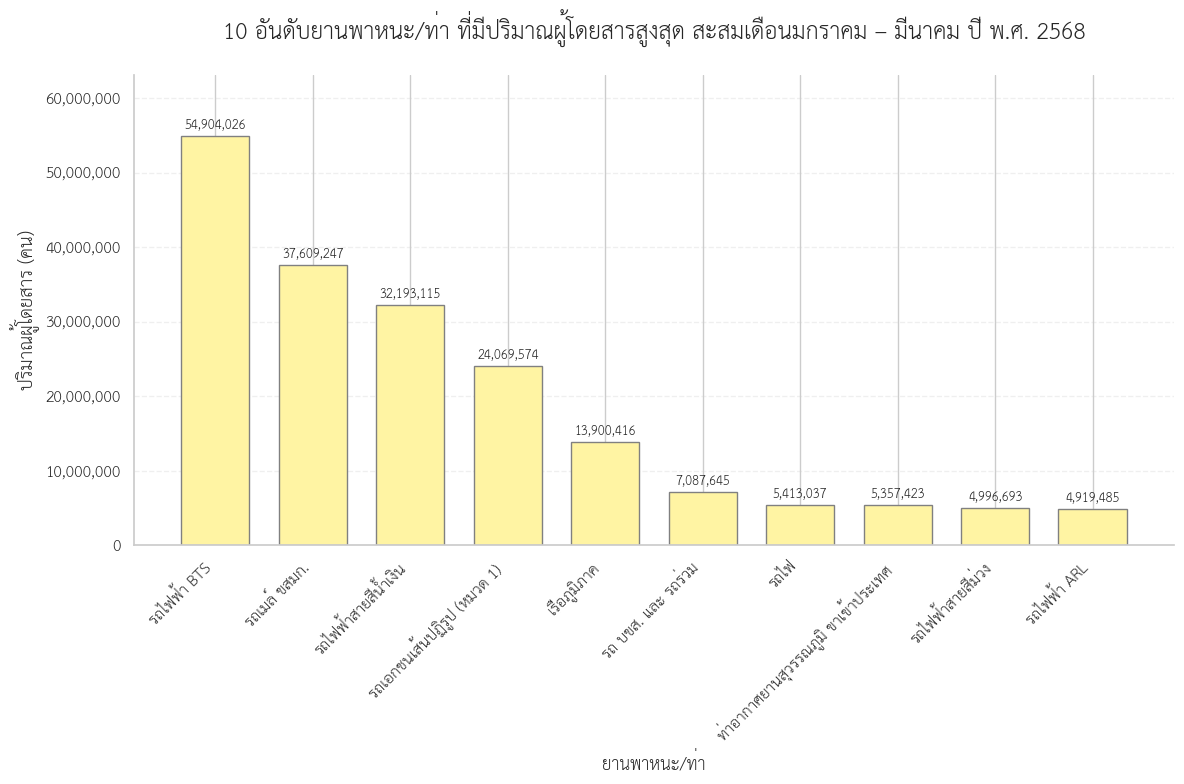

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
ตารางสรุป 10 อันดับยานพาหนะ/ท่า ที่มีปริมาณผู้โดยสารสูงสุด สะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2568


,ปริมาณผู้โดยสารทั้งหมด (คน)
ยานพาหนะ/ท่า,
รถไฟฟ้า BTS,"54,904,026"
รถเมล์ ขสมก.,"37,609,247"
รถไฟฟ้าสายสีน้ำเงิน,"32,193,115"
รถเอกชนเส้นปฏิรูป (หมวด 1),"24,069,574"
เรือภูมิภาค,"13,900,416"
รถ บขส. และ รถร่วม,"7,087,645"
รถไฟ,"5,413,037"
ท่าอากาศยานสุวรรณภูมิ ขาเข้าประเทศ,"5,357,423"
รถไฟฟ้าสายสีม่วง,"4,996,693"


In [ ]:
# --- Vehicle/Station (ยานพาหนะ/ท่า ที่เกี่ยวข้องกับการเดินทาง) ---

# ตั้งค่าให้ Pandas แสดงคอมม่าสำหรับตัวเลขจำนวนเต็ม (Global Setting)
pd.options.display.float_format = '{:,.0f}'.format

# 1. คำนวณผลรวม (จัดเรียงจากมากไปน้อย)
vs_sum_68_3m = df_2568_3m.groupby('ยานพาหนะ/ท่า')['ปริมาณ'].sum().sort_values(ascending=False).head(10).to_frame(name='ปริมาณผู้โดยสารทั้งหมด (คน)')

# 2. Bar chart (หน่วย: คน)
plt.figure(figsize=(12, 8))

bars = plt.bar(vs_sum_68_3m.index, vs_sum_68_3m ['ปริมาณผู้โดยสารทั้งหมด (คน)'],
               color='#FFF4A3',
               edgecolor='grey',
               width=0.7)

# เพิ่ม Data Labels บนแท่ง (หน่วยคน พร้อมคอมม่า)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (vs_sum_68_3m ['ปริมาณผู้โดยสารทั้งหมด (คน)'].max() * 0.01),
             f'{yval:,.0f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# ปรับการตั้งค่าแกน Y ให้แสดงเลขเต็มพร้อมคอมม่า (ป้องกัน 1e8)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('10 อันดับยานพาหนะ/ท่า ที่มีปริมาณผู้โดยสารสูงสุด สะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2568', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('ยานพาหนะ/ท่า', fontsize=12)
plt.ylabel('ปริมาณผู้โดยสาร (คน)', fontsize=13, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# เผื่อพื้นที่ด้านบนให้ Data Label
plt.ylim(0, vs_sum_68_3m['ปริมาณผู้โดยสารทั้งหมด (คน)'].max() * 1.15)

plt.tight_layout()
plt.show()

# 3. แสดงตารางประกอบ
print("-" * 300)
print("ตารางสรุป 10 อันดับยานพาหนะ/ท่า ที่มีปริมาณผู้โดยสารสูงสุด สะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2568")
display(vs_sum_68_3m.style.format("{:,.0f}"))

##### Snapshot: Passenger 2026 (๋Jan-Mar)
> เจาะลึก ปริมาณผู้โดยสารสะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2569

In [ ]:
##################### ปริมาณผู้โดยสาร (หน่วย:คน) #####################
## --------------- ปริมาณผู้โดยสารสะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2569 ---------------
df_people_69 = df_2569_y[df_2569_y['หน่วย'] == 'คน']
total_people_69 = df_people_69['ปริมาณ'].sum()
print(f"ปริมาณผู้โดยสารสะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2569 : {total_people_69:,} คน")

ปริมาณผู้โดยสารสะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2569 : 215,911,577 คน


###### Purpose
> วัตถุประสงค์ของการเดินทาง

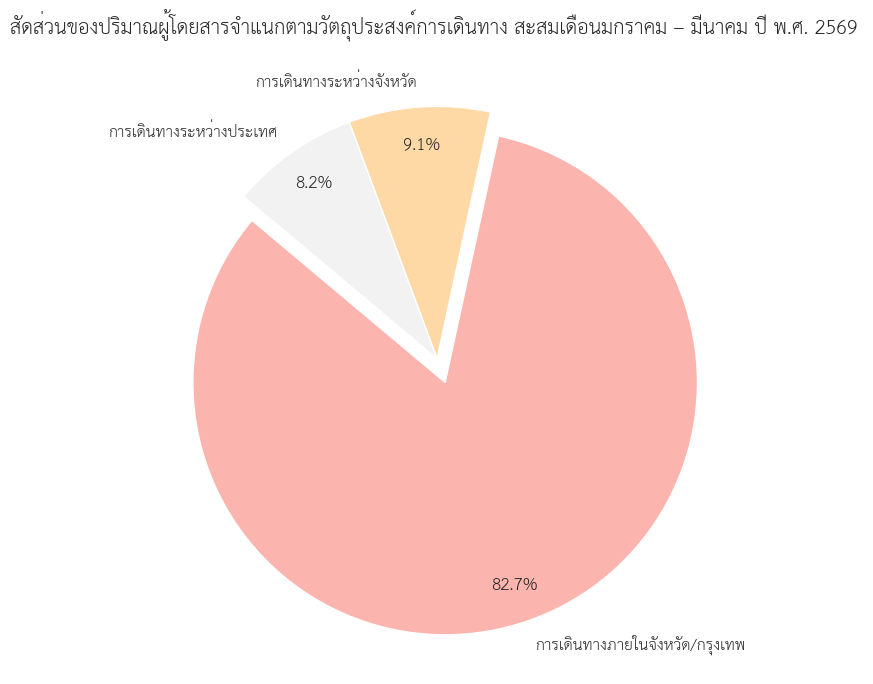

In [ ]:
# --- Purpose ( วัตถุประสงค์ของการเดินทาง) ---

# ตั้งค่าให้ Pandas แสดงคอมม่าสำหรับตัวเลขจำนวนเต็ม (Global Setting)
pd.options.display.float_format = '{:,.0f}'.format

# 1. คำนวณผลรวมของปริมาณแยกตามวัตถุประสงค์
purpose_sum_69_3m = df_people_69.groupby('วัตถุประสงค์')['ปริมาณ'].sum().sort_values(ascending=False).to_frame(name='ปริมาณผู้โดยสารทั้งหมด (คน)')

# 2. Pie Chart
plt.figure(figsize=(10, 7))
purpose_sum_69_3m['ปริมาณผู้โดยสารทั้งหมด (คน)'].plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    cmap='Pastel1',
    pctdistance=0.85,
    explode=[0.1 if i == 0 else 0 for i in range(len(purpose_sum_69_3m))]
)

plt.title('สัดส่วนของปริมาณผู้โดยสารจำแนกตามวัตถุประสงค์การเดินทาง สะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2569 ', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

###### Mode
> รูปแบบการเดินทาง



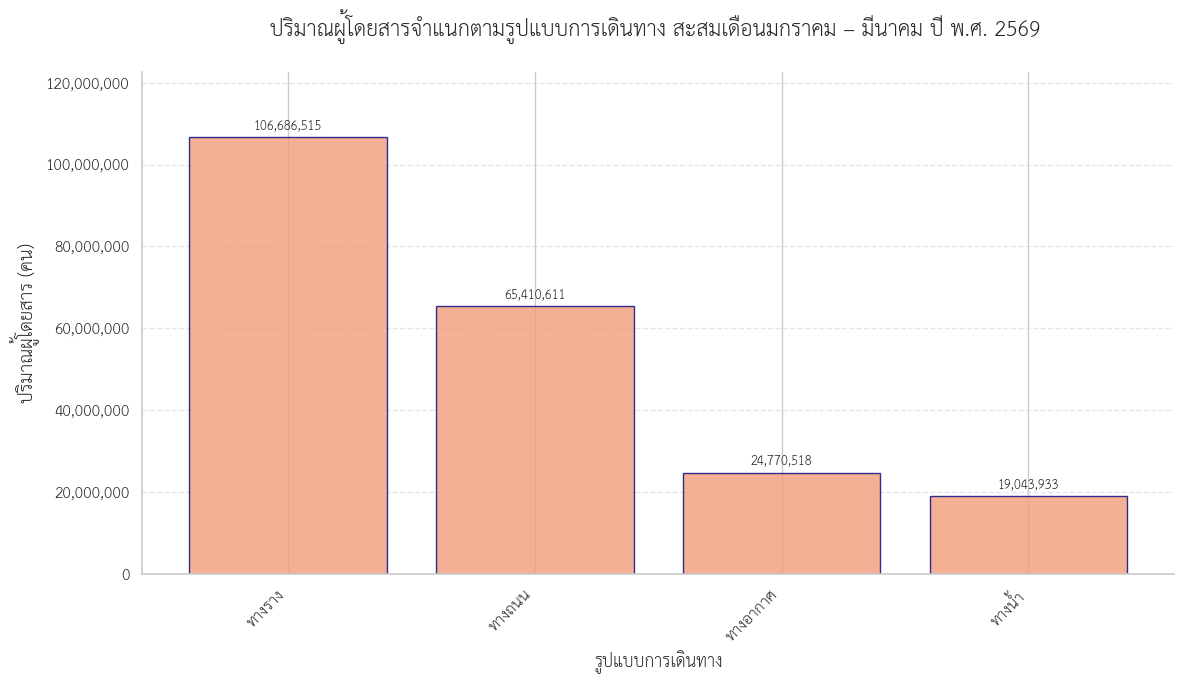

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
ตารางสรุปปริมาณผู้โดยสารจำแนกตามรูปแบบการเดินทาง สะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2569


,ปริมาณผู้โดยสารทั้งหมด (คน)
รูปแบบการเดินทาง,
ทางราง,"106,686,515"
ทางถนน,"65,410,611"
ทางอากาศ,"24,770,518"
ทางน้ำ,"19,043,933"


In [ ]:
# --- Mode (รูปแบบการเดินทาง) ---

# ตั้งค่าให้ Pandas แสดงคอมม่าสำหรับตัวเลขจำนวนเต็ม (Global Setting)
pd.options.display.float_format = '{:,.0f}'.format

# 1. คำนวณผลรวม (จัดเรียงจากมากไปน้อย)
mode_sum_69_3m = df_people_69.groupby('รูปแบบการเดินทาง')['ปริมาณ'].sum().sort_values(ascending=False).to_frame(name='ปริมาณผู้โดยสารทั้งหมด (คน)')

# 2. Bar Chart
plt.figure(figsize=(12, 7))
bars = plt.bar(mode_sum_69_3m.index, mode_sum_69_3m['ปริมาณผู้โดยสารทั้งหมด (คน)'],
               color='#F19C79',
               edgecolor='navy',
               alpha=0.8)

# เพิ่มตัวเลขกำกับบนแต่ละแท่ง (Data Labels - แสดงหน่วยคนพร้อมคอมม่า)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (mode_sum_69_3m['ปริมาณผู้โดยสารทั้งหมด (คน)'].max() * 0.01),
             f'{yval:,.0f}',
             ha='center',
             va='bottom',
             fontsize=9,
             fontweight='bold')

# --- ตั้งค่าแกน Y ให้แสดงเลขเต็มพร้อมคอมม่า (ป้องกัน 1e8) ---
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('ปริมาณผู้โดยสารจำแนกตามรูปแบบการเดินทาง สะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2569 ', fontsize=15, pad=25, fontweight='bold')
plt.xlabel('รูปแบบการเดินทาง', fontsize=12)
plt.ylabel('ปริมาณผู้โดยสาร (คน)', fontsize=13, fontweight='bold')

# หมุนชื่อแกน X และปรับ Grid
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# ลบเส้นขอบด้านบนและด้านขวาเพื่อให้กราฟดูสะอาดขึ้น
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# เผื่อพื้นที่ด้านบนให้ตัวเลข Data Label
plt.ylim(0, mode_sum_69_3m['ปริมาณผู้โดยสารทั้งหมด (คน)'].max() * 1.15)

plt.tight_layout()
plt.show()

# 3. แสดงตารางประกอบ
print("-" * 300)
print("ตารางสรุปปริมาณผู้โดยสารจำแนกตามรูปแบบการเดินทาง สะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2569")
display(mode_sum_69_3m.style.format("{:,.0f}"))

###### Vehicle/Station
> ยานพาหนะ/ท่า ที่เกี่ยวข้องกับการเดินทาง

- Top 10 Vehicles/Station by Passenger

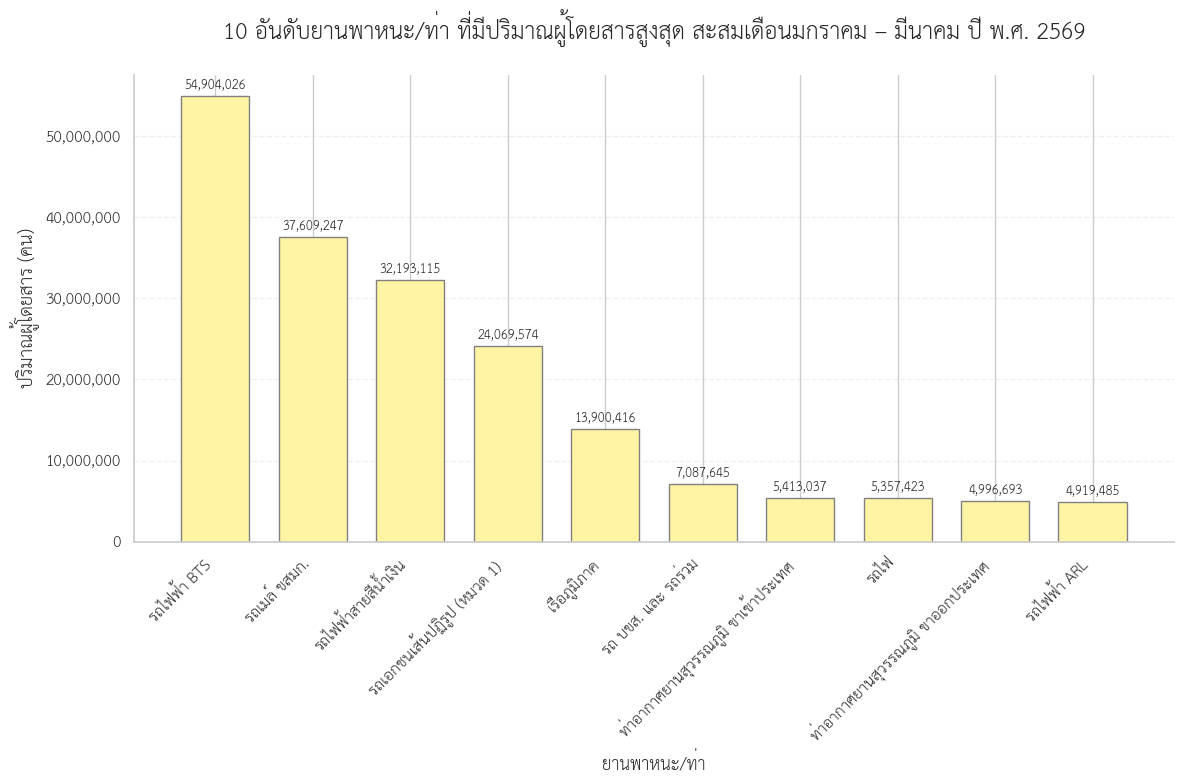

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
ตารางสรุป 10 อันดับยานพาหนะ/ท่า ที่มีปริมาณผู้โดยสารสูงสุด สะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2569


,ปริมาณผู้โดยสารทั้งหมด (คน)
ยานพาหนะ/ท่า,
รถไฟฟ้า BTS,"50,044,667"
รถเมล์ ขสมก.,"35,604,084"
รถไฟฟ้าสายสีน้ำเงิน,"31,264,222"
รถเอกชนเส้นปฏิรูป (หมวด 1),"23,127,808"
เรือภูมิภาค,"14,716,787"
รถ บขส. และ รถร่วม,"6,394,257"
ท่าอากาศยานสุวรรณภูมิ ขาเข้าประเทศ,"5,564,700"
รถไฟ,"5,481,521"
ท่าอากาศยานสุวรรณภูมิ ขาออกประเทศ,"5,041,566"


In [ ]:
# --- Vehicle/Station (ยานพาหนะ/ท่า ที่เกี่ยวข้องกับการเดินทาง) ---

# ตั้งค่าให้ Pandas แสดงคอมม่าสำหรับตัวเลขจำนวนเต็ม (Global Setting)
pd.options.display.float_format = '{:,.0f}'.format

# 1. คำนวณผลรวม (จัดเรียงจากมากไปน้อย)
vs_sum_69_3m = df_people_69.groupby('ยานพาหนะ/ท่า')['ปริมาณ'].sum().sort_values(ascending=False).head(10).to_frame(name='ปริมาณผู้โดยสารทั้งหมด (คน)')

# 2. Bar chart (หน่วย: คน)
plt.figure(figsize=(12, 8))

bars = plt.bar(vs_sum_69_3m.index, vs_sum_68_3m ['ปริมาณผู้โดยสารทั้งหมด (คน)'],
               color='#FFF4A3',
               edgecolor='grey',
               width=0.7)

# เพิ่ม Data Labels บนแท่ง (หน่วยคน พร้อมคอมม่า)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (vs_sum_69_3m ['ปริมาณผู้โดยสารทั้งหมด (คน)'].max() * 0.01),
             f'{yval:,.0f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# ปรับการตั้งค่าแกน Y ให้แสดงเลขเต็มพร้อมคอมม่า (ป้องกัน 1e8)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('10 อันดับยานพาหนะ/ท่า ที่มีปริมาณผู้โดยสารสูงสุด สะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2569', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('ยานพาหนะ/ท่า', fontsize=12)
plt.ylabel('ปริมาณผู้โดยสาร (คน)', fontsize=13, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# เผื่อพื้นที่ด้านบนให้ Data Label
plt.ylim(0, vs_sum_69_3m['ปริมาณผู้โดยสารทั้งหมด (คน)'].max() * 1.15)

plt.tight_layout()
plt.show()

# 3. แสดงตารางประกอบ
print("-" * 300)
print("ตารางสรุป 10 อันดับยานพาหนะ/ท่า ที่มีปริมาณผู้โดยสารสูงสุด สะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2569")
display(vs_sum_69_3m.style.format("{:,.0f}"))

##### **Summary Snapshot 3 Month**
> Passenger 2025 (Jan-Mar) and 2026 (Jan-Mar)

> ปริมาณผู้โดยสารสะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2568 เเละ ปี พ.ศ. 2569
---

1. สรุปข้อมูลปริมาณผู้โดยสารสะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2568 เเละ ปี พ.ศ. 2569
      | พ.ศ.| ปริมาณผู้โดยสาร (คน) | วัตถุประสงค์ของการเดินทาง | รูปแบบการเดินทาง |
      | :--- | :--- | :--- |:--- |
      |2568 | 224,072,745 | การเดินทางภายในจังหวัด/กรุงเทพ | ทางราง |
      |2569 | 215,911,577 | การเดินทางภายในจังหวัด/กรุงเทพ | ทางราง |

---
2. สรุปยานพาหนะ/ท่า ที่มีปริมาณผู้โดยสารสูงสุด สะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2568 เเละ ปี พ.ศ. 2569

    2.1 ปี พ.ศ. 2568
    | อันดับ | ยานพาหนะ/ท่า | ปริมาณผู้โดยสาร (คน) |
    |:---|:---|---:|
    | 1 | รถไฟฟ้า BTS | 54,904,026 |
    | 2 | รถเมล์ ขสมก. | 37,609,247 |
    | 3 | รถไฟฟ้าสายสีน้ำเงิน | 32,193,115 |
    | 4 | รถเอกชนเส้นปฏิรูป (หมวด 1) | 24,069,574 |
    | 5 | เรือภูมิภาค | 13,900,416 |
    | 6 | รถ บขส. และ รถร่วม | 7,087,645 |
    | 7 | รถไฟ | 5,413,037 |
    | 8 | ท่าอากาศยานสุวรรณภูมิ ขาเข้าประเทศ | 5,357,423 |
    | 9 | รถไฟฟ้าสายสีม่วง | 4,996,693 |
    | 10 | รถไฟฟ้า ARL | 4,919,485 |

    2.2 ปี พ.ศ. 2569
    | อันดับ | ยานพาหนะ/ท่า | ปริมาณผู้โดยสาร (คน) |
    |:---|:---|---:|
    | 1 | รถไฟฟ้า BTS | 50,044,667 |
    | 2 | รถเมล์ ขสมก. | 35,604,084 |
    | 3 | รถไฟฟ้าสายสีน้ำเงิน | 31,264,222 |
    | 4 | รถเอกชนเส้นปฏิรูป (หมวด 1) | 23,127,808 |
    | 5 | เรือภูมิภาค | 14,716,787 |
    | 6 | รถ บขส. และ รถร่วม | 6,394,257 |
    | 7 | ท่าอากาศยานสุวรรณภูมิ ขาเข้าประเทศ | 5,564,700 |
    | 8 | รถไฟ | 5,481,521 |
    | 9 | ท่าอากาศยานสุวรรณภูมิ ขาออกประเทศ | 5,041,566 |
    | 10 | รถไฟฟ้า ARL | 5,011,541 |

---

3. สรุปรูปแบบที่เติบโตหรือหดตัว สะสมเดือนมกราคม – มีนาคม ปี พ.ศ. 2568 เเละ ปี พ.ศ. 2569

    3.1 วัตถุประสงค์ของการเดินทาง : เดินทางภายในจังหวัด/กรุงเทพ
      - ปี พ.ศ. 2568 คิดเป็นร้อยละ 83.5
      - ปี พ.ศ. 2569 คิดเป็นร้อยละ 82.7
    > สรุป : การเดินทางภายในจังหวัด/กรุงเทพ 'หดตัว'

    3.2 รูปแบบการเดินทาง : เดินทางด้วยราง
      - ปี พ.ศ. 2568 คิดเป็น 112,876,950 คน (คิดเป็นร้อยละ 50.4)
      - ปี พ.ศ. 2569 คิดเป็น 106,686,515 คน (คิดเป็นร้อยละ 49.4)
    > สรุป : รูปแบบการเดินทางด้วยรางมีการ 'หดตัว'

    3.3 ยานพาหนะ/ท่า : รถไฟฟ้า BTS
      - ปี พ.ศ. 2568 คิดเป็น 54,904,026 คน (คิดเป็นร้อยละ 24.5)
      - ปี พ.ศ. 2569 คิดเป็น 50,044,667  คน (คิดเป็นร้อยละ 23.2)
    > สรุป : การเดินทางด้วยยานพาหนะอย่างรถไฟฟ้า BTS มีการ 'หดตัว'



#### 3.2 Deep Trend: High-Volume Segments (15 Month)
> เจาะจง (Focus) กลุ่มผู้โดยสารส่วนใหญ่ทั้งหมด 15 เดือน (ม.ค. 2568 – มี.ค. 2569)

In [ ]:
##################### ปริมาณผู้โดยสาร (หน่วย:คน) #####################
## --------------- ข้อมูลปริมาณผู้โดยสารรวม 15 เดือน (ม.ค. 2568 – มี.ค. 2569) -----------------

df_people_c= df_combined[df_combined['หน่วย'] == 'คน']
total_people_c = df_people_c['ปริมาณ'].sum()
print(f"ปริมาณผู้โดยสารรวม 15 เดือน (ม.ค. 2568 – มี.ค. 2569) : {total_people_c:,} คน")

ปริมาณผู้โดยสารรวม 15 เดือน (ม.ค. 2568 – มี.ค. 2569) : 1,290,227,300 คน


#####  Monthly Trend

###### Segment by Vehicle/Station (15 Month)
> วิเคราะห์ปริมาณผู้โดยสารจำเเนกยานพาหนะ/ท่า ที่เกี่ยวข้องกับการเดินทาง

          - วัตถุประสงค์ของการเดินทาง : เดินทางภายในจังหวัด/กรุงเทพ
          - รูปแบบการเดินทาง : เดินทางด้วยราง


In [ ]:
df_people_c.columns

Index(['รูปแบบการเดินทาง', 'วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล', 'หน่วยงาน',
       'ยานพาหนะ/ท่า', 'วันที่', 'หน่วย', 'ปริมาณ', 'year', 'month', 'day',
       'quarter', 'day_of_week', 'is_weekend', 'day_num', 'ปี'],
      dtype='object')

In [ ]:
##################### ปริมาณผู้โดยสาร (หน่วย:คน) #####################
## --------------- ข้อมูลปริมาณผู้โดยสารรวม 15 เดือน (ม.ค. 2568 – มี.ค. 2569) -----------------

df_people_c= df_combined[df_combined['หน่วย'] == 'คน']
df_filter = df_people_c[
    (df_people_c['วัตถุประสงค์'] == 'การเดินทางภายในจังหวัด/กรุงเทพ') &
    (df_people_c['รูปแบบการเดินทาง'] == 'ทางราง')
].copy()

total_people_f = df_filter['ปริมาณ'].sum()
print(f"ปริมาณผู้โดยสารที่เดินทางภายในจังหวัด/กรุงเทพ โดยใช้การเดินทางเเบบราง รวม 15 เดือน (ม.ค. 2568 – มี.ค. 2569) : {total_people_f:,} คน")

ปริมาณผู้โดยสารที่เดินทางภายในจังหวัด/กรุงเทพ โดยใช้การเดินทางเเบบราง รวม 15 เดือน (ม.ค. 2568 – มี.ค. 2569) : 620,319,223 คน


In [ ]:
# แปลงเดือนภาษาไทย + ปี พ.ศ.
month_th = {
    1: 'มกราคม', 2: 'กุมภาพันธ์', 3: 'มีนาคม', 4: 'เมษายน',
    5: 'พฤษภาคม', 6: 'มิถุนายน', 7: 'กรกฎาคม', 8: 'สิงหาคม',
    9: 'กันยายน', 10: 'ตุลาคม', 11: 'พฤศจิกายน', 12: 'ธันวาคม'
}

def to_thai_label(period):
    return f"{month_th[period.month]} {period.year + 543}"

In [ ]:
# --- Segment by Vehicle/Station (15 Month) ---

# 1. Filter
df_filter = df_people_c[
    (df_people_c['วัตถุประสงค์'] == 'การเดินทางภายในจังหวัด/กรุงเทพ') &
    (df_people_c['รูปแบบการเดินทาง'] == 'ทางราง')
].copy()

# 2. จัดรูปแบบวันที่
df_filter['วันที่'] = pd.to_datetime(df_filter['วันที่'])
df_filter['MonthYear_dt'] = df_filter['วันที่'].dt.to_period('M')
df_filter['MonthYear']    = df_filter['MonthYear_dt'].apply(to_thai_label)

# 3. Pivot + เรียงตามเวลา + 15 เดือน
pivot_df = (
    df_filter
    .pivot_table(
        index=['MonthYear_dt', 'MonthYear'],
        columns='ยานพาหนะ/ท่า',
        values='ปริมาณ',
        aggfunc='sum'
    )
    .fillna(0)
    .sort_index(level='MonthYear_dt')
    .tail(15)
)

# --- เรียงลำดับคอลัมน์ (ยานพาหนะ) ตาม ปริมาณผู้โดยสารรวมจากมากไปน้อย ---
total_by_vehicle = pivot_df.sum().sort_values(ascending=False)
pivot_df = pivot_df[total_by_vehicle.index]
pivot_df.index = pivot_df.index.get_level_values('MonthYear')

categories = pivot_df.index.tolist()
vehicles   = pivot_df.columns.tolist()

# 4. Pastel palette
palette = [
    '#2E5077',  # สีครามเข้ม (Deep Indigo - สุขุม มืออาชีพ)
    '#AED6F1',  # น้ำเงินอ่อน (Light Sky Blue)
    '#D2B4DE',  # ม่วงอ่อน (Lavender)
    '#922B21',  # สีแดงเข้ม (Deep Muted Red - ชัดเจนแต่ดูแพง)
    '#F5B7B1',  # ชมพู (Soft Pink)
    '#F9E79F',  # เหลือง (Pale Yellow)
    '#F1948A'   # แดงอ่อน (Soft Coral)
]

# 5. สร้าง Figure
fig = go.Figure()

for i, vehicle in enumerate(vehicles):
    fig.add_trace(go.Bar(
        name=vehicle,
        x=categories,
        y=pivot_df[vehicle].values,
        marker_color=palette[i % len(palette)],
        # ลบ offsetgroup=str(i) ออกเพื่อให้ Plotly จัดการตำแหน่งให้อัตโนมัติ (จะเรียงตามลำดับ Trace)
        hovertemplate=f'<b>{vehicle}</b><br>เดือน: %{{x}}<br>ปริมาณ: %{{y:,.0f}} คน<extra></extra>'
    ))

# 6. Layout
fig.update_layout(
    font=dict(family='TH Sarabun New', size=20),
    title=dict(
        text='ปริมาณผู้โดยสารที่เดินทางภายในจังหวัด/กรุงเทพ โดยใช้การเดินทางเเบบราง จำแนกยานพาหนะ/ท่า ทั้งหมด 15 เดือน (ม.ค. 2568 – มี.ค. 2569)',
        font=dict(size=30),
        x=0.5
    ),
    barmode='group',
    xaxis=dict(
        title='เดือน ปี',
        tickangle=-35,
        tickfont=dict(size=20),
        showgrid=False,
        showline=True,
        linecolor='#CCCCCC'
    ),
    yaxis=dict(
        title='ปริมาณผู้โดยสาร (คน)',
        tickformat=',.0f',
        tickfont=dict(size=20),
        showgrid=True,
        gridcolor='rgba(200,200,200,0.4)',
        rangemode='tozero'
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5,
        font=dict(size=20)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=650,   # สูงขึ้น
    width=1300,   # กว้างขึ้น
    margin=dict(t=120, b=100, l=80, r=40)
)

for i in range(1, len(categories)):
    fig.add_vline(x=i - 0.5, line=dict(color='#DDDDDD', width=1))

fig.show()

In [ ]:
# --- สร้างตารางสรุป ---
# --- 1. เตรียมข้อมูลแยก ปี และ เดือน ---
# เราจะ split ด้วยช่องว่างเพื่อแยกเป็น 2 ลิสต์
months = [str(x).split(' ')[0] for x in pivot_df.index]
years = [str(x).split(' ')[1] if len(str(x).split(' ')) > 1 else '' for x in pivot_df.index]

# --- 2. สร้างตารางแบบแยกคอลัมน์ ---
fig = go.Figure(data=[go.Table(
    columnorder = [1, 2] + list(range(3, len(vehicles) + 3)),
    columnwidth = [80, 100] + [120] * len(vehicles),
    header=dict(
        values=['<b>ปี</b>', '<b>เดือน</b>'] + [f'<b>{v}</b>' for v in vehicles],
        fill_color='white',
        align='center',
        line_color='black',
        font=dict(family='TH Sarabun New', size=20)
    ),
    cells=dict(
        # ใส่ลิสต์ years และ months แยกกันเป็น 2 คอลัมน์แรก
        values=[years, months] + [pivot_df[v].tolist() for v in vehicles],
        fill_color='white',
        align='center',
        line_color='black',
        format=[None, None] + [',.0f'] * len(vehicles), # ตัวเลขใส่คอมมา
        font=dict(family='TH Sarabun New', size=20),
        height=30
    )
)])

# ปรับ Layout
fig.update_layout(
    title=dict(
        text='ตารางปริมาณผู้โดยสารที่เดินทางภายในจังหวัด/กรุงเทพ โดยใช้การเดินทางเเบบราง จำแนกยานพาหนะ/ท่า ทั้งหมด 15 เดือน (ม.ค. 2568 – มี.ค. 2569)',
        font=dict(family='TH Sarabun New', size=30),
        x=0.5
    ),
    margin=dict(l=20, r=20, t=80, b=20),
    width=1300,
    height=700
)

fig.show()

##### Daily Trend

In [ ]:
def to_thai_date(dt):
    return f"{dt.day} {month_th[dt.month]} {dt.year + 543}"

In [ ]:
# --- Daily Trend by Vehicle/Station (15 Month) ---

# 1. Filter
df_filter = df_people_c[
    (df_people_c['วัตถุประสงค์'] == 'การเดินทางภายในจังหวัด/กรุงเทพ') &
    (df_people_c['รูปแบบการเดินทาง'] == 'ทางราง')
].copy()

# 2. จัดรูปแบบวันที่
df_filter['วันที่'] = pd.to_datetime(df_filter['วันที่'])

# 3. Pivot รายวัน + เรียงตามเวลา
pivot_df = (
    df_filter
    .pivot_table(
        index='วันที่',
        columns='ยานพาหนะ/ท่า',
        values='ปริมาณ',
        aggfunc='sum'
    )
    .fillna(0)
    .sort_index()
)

# ตัด 15 เดือนล่าสุด
cutoff_date = pivot_df.index.max() - pd.DateOffset(months=15)
pivot_df = pivot_df[pivot_df.index > cutoff_date]

# เรียงคอลัมน์ตามปริมาณรวมจากมากไปน้อย
total_by_vehicle = pivot_df.sum().sort_values(ascending=False)
pivot_df = pivot_df[total_by_vehicle.index]

vehicles = pivot_df.columns.tolist()

# สร้าง label ภาษาไทย พ.ศ. สำหรับ hover
thai_dates = [to_thai_date(d) for d in pivot_df.index]

# สร้าง tick positions (ต้นเดือน) และ labels ภาษาไทย
month_starts = pd.date_range(
    start=pivot_df.index.min().to_period('M').to_timestamp(),
    end=pivot_df.index.max().to_period('M').to_timestamp(),
    freq='MS'
)
tick_vals  = month_starts
tick_texts = [f"{month_th[d.month]}\n{d.year + 543}" for d in month_starts]

# 4. Palette
palette = [
    '#2E5077',
    '#AED6F1',
    '#D2B4DE',
    '#922B21',
    '#F5B7B1',
    '#F9E79F',
    '#F1948A'
]

# 5. สร้าง Figure
fig = go.Figure()

for i, vehicle in enumerate(vehicles):
    fig.add_trace(go.Scatter(
        name=vehicle,
        x=pivot_df.index,
        y=pivot_df[vehicle].values,
        mode='lines',
        line=dict(
            color=palette[i % len(palette)],
            width=1.8
        ),
        customdata=thai_dates,
        hovertemplate=(
            f'<b>{vehicle}</b><br>'
            'วันที่: %{customdata}<br>'
            'ปริมาณ: %{y:,.0f} คน'
            '<extra></extra>'
        )
    ))

# 6. Layout
fig.update_layout(
    font=dict(family='TH Sarabun New', size=20),
    title=dict(
        text='ปริมาณผู้โดยสารรายวัน ที่เดินทางภายในจังหวัด/กรุงเทพ โดยใช้การเดินทางแบบราง จำแนกยานพาหนะ/ท่า (15 เดือน)',
        font=dict(size=30),
        x=0.5
    ),
    xaxis=dict(
        title='วันที่',
        tickvals=tick_vals,
        ticktext=tick_texts,
        tickangle=-35,
        tickfont=dict(size=20),
        showgrid=True,
        gridcolor='rgba(200,200,200,0.3)',
        showline=True,
        linecolor='#CCCCCC',
    ),
    yaxis=dict(
        title='ปริมาณผู้โดยสาร (คน)',
        tickformat=',.0f',
        tickfont=dict(size=20),
        showgrid=True,
        gridcolor='rgba(200,200,200,0.4)',
        rangemode='tozero'
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5,
        font=dict(size=20)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=650,
    width=1400,
    margin=dict(t=120, b=80, l=80, r=40),
    hovermode='x unified'
)

fig.show()

##### **Summary Deep Trend 15 Month**
> Passenger (Jan 2568 – Mar 2569)

> ปริมาณผู้โดยสารส่วนใหญ่ทั้งหมด 15 เดือน (ม.ค. 2568 – มี.ค. 2569)
---

1. สรุปข้อมูลรถไฟฟ้าสายใดที่มีความผันผวนสูง เเละ สายใดที่มีความเสถียร โดยใช้
ปริมาณผู้โดยสารสะสมเดือนมกราคม  พ.ศ. 2568 – มีนาคม ปี พ.ศ. 2569
    
    1.1 รถไฟฟ้าที่มีความผันผวนสูง : BTS
    > เนื่องจาก รถไฟฟ้า BTS มีกราฟฟันปลาชัดเจน ปริมาณผู้โดยสารแกว่งระหว่าง 400,000 ถึง 1,200,000 คน/วัน โดยจุดพีคสูงสุดช่วง 25–31 มกราคม 2568 เกิดจากนโยบายรัฐบาลส่งเสริมใช้ขนส่งสาธารณะฟรีเพื่อลด PM 2.5 (อ้างอิงโครงสร้างพื้นฐาน ประเทศไทย Thailand Infrastructure, 2568) ทำให้ยอดปริมาณผู้โดยสารเพิ่มขึ้น นอกจากนี้ยังมีการแกว่งตัวรายสัปดาห์ตามวันทำงาน-วันหยุด

    1.2 รถไฟฟ้าที่มีความเสถียร : MRT (สีแดง, สีม่วง, สีเหลือง, สีชมพู) เเละ ARL
    > เนื่องจาก รถไฟฟ้า MRT เเละ ARL เป็นกลุ่มรถไฟฟ้าสายรอง ให้บริการผู้เดินทางประจำ (Commuters) ที่ใช้เส้นทางเดิมซ้ำทุกวัน ความต่างระหว่างวันทำงาน-วันหยุดมีน้อยมาก จะเห้นได้ว่า เส้นกราฟแบนราบและนิ่งตลอด 15 เดือน โดยเฉพาะ ARL ที่ฐานผู้โดยสารผูกกับการเดินทางไป-กลับสนามบินซึ่งคาดการณ์ได้ค่อนข้างแน่นอน สะท้อนความต้องการใช้งานที่สม่ำเสมอและไม่ขึ้นกับฤดูกาลหรือปัจจัยภายนอก



#### 3.3 Event Detection

In [ ]:
##################### ปริมาณผู้โดยสาร (หน่วย:คน) #####################
## --------------- ข้อมูลปริมาณผู้โดยสารรวม 15 เดือน (ม.ค. 2568 – มี.ค. 2569) -----------------

df_people_c= df_combined[df_combined['หน่วย'] == 'คน']
total_people_c = df_people_c['ปริมาณ'].sum()
print(f"ปริมาณผู้โดยสารรวม 15 เดือน (ม.ค. 2568 – มี.ค. 2569) : {total_people_c:,} คน")

ปริมาณผู้โดยสารรวม 15 เดือน (ม.ค. 2568 – มี.ค. 2569) : 1,290,227,300 คน


##### Daily Trend

In [ ]:
# --- Daily Trend & Event Detection (15 เดือน) ---
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display # นำเข้า display เผื่อรันใน Jupyter/Colab

# 1. จัดกลุ่มข้อมูลปริมาณผู้โดยสารรวมทุกรูปแบบรายวัน
df_daily = df_people_c.groupby('วันที่')['ปริมาณ'].sum().reset_index()
df_daily['วันที่'] = pd.to_datetime(df_daily['วันที่'])
df_daily = df_daily.sort_values('วันที่')

# 2. คำนวณค่าทางสถิติ
mean_vol = df_daily['ปริมาณ'].mean()
std_vol = df_daily['ปริมาณ'].std()
upper_bound = mean_vol + (1.5 * std_vol)
lower_bound = mean_vol - (1.5 * std_vol)

# 3. ติด Label Anomaly
def detect_anomaly(val):
    if val > upper_bound:
        return 'High Peak'
    elif val < lower_bound:
        return 'Low Drop'
    else:
        return 'Normal'

df_daily['Event_Type'] = df_daily['ปริมาณ'].apply(detect_anomaly)

# 4. แปลงวันที่เป็นภาษาไทย
month_th_full = {1: 'มกราคม', 2: 'กุมภาพันธ์', 3: 'มีนาคม', 4: 'เมษายน',
                 5: 'พฤษภาคม', 6: 'มิถุนายน', 7: 'กรกฎาคม', 8: 'สิงหาคม',
                 9: 'กันยายน', 10: 'ตุลาคม', 11: 'พฤศจิกายน', 12: 'ธันวาคม'}

month_th_short = {1: 'ม.ค.', 2: 'ก.พ.', 3: 'มี.ค.', 4: 'เม.ย.',
                  5: 'พ.ค.', 6: 'มิ.ย.', 7: 'ก.ค.', 8: 'ส.ค.',
                  9: 'ก.ย.', 10: 'ต.ค.', 11: 'พ.ย.', 12: 'ธ.ค.'}

def to_thai_date(dt):
    return f"{dt.day} {month_th_full[dt.month]} {dt.year + 543}"

df_daily['Thai_Date'] = df_daily['วันที่'].apply(to_thai_date)

# ============================================================
# ★ Dictionary เหตุการณ์สำคัญ
# ============================================================
events_dict = {
    # วันหยุดนักขัตฤกษ์และเทศกาล ปี 2568
    '2025-01-01': 'วันปีใหม่',
    '2025-01-02': 'วันหยุดชดเชยปีใหม่',
    '2025-01-28': 'ตรุษจีน',
    '2025-01-29': 'ตรุษจีน (วันที่ 2)',
    '2025-01-30': 'ตรุษจีน (วันที่ 3)',
    '2025-02-12': 'วันมาฆบูชา',
    '2025-02-14': 'วาเลนไทน์',
    '2025-04-06': 'วันจักรี',
    '2025-04-13': 'วันสงกรานต์',
    '2025-04-14': 'วันสงกรานต์ (วันที่ 2)',
    '2025-04-15': 'วันสงกรานต์ (วันที่ 3)',
    '2025-05-01': 'วันแรงงานแห่งชาติ',
    '2025-05-05': 'วันฉัตรมงคล',
    '2025-05-12': 'วันวิสาขบูชา',
    '2025-06-03': 'วันเฉลิมพระชนมพรรษา ร.10 (ทรงพระเจริญ)',
    '2025-07-11': 'วันอาสาฬหบูชา',
    '2025-07-12': 'วันเข้าพรรษา',
    '2025-07-28': 'วันเฉลิมพระชนมพรรษา ร.10',
    '2025-08-12': 'วันแม่แห่งชาติ',
    '2025-10-13': 'วันคล้ายวันสวรรคต ร.9',
    '2025-10-23': 'วันปิยมหาราช',
    '2025-12-05': 'วันพ่อแห่งชาติ',
    '2025-12-10': 'วันรัฐธรรมนูญ',
    '2025-12-31': 'วันสิ้นปี',
    # ปี 2569
    '2026-01-01': 'วันปีใหม่ 2569',
}

#เพิ่มเหตุการณ์พิเศษ
pm25_event = 'นโยบายรัฐบาลส่งเสริมใช้ขนส่งสาธารณะฟรีเพื่อลด PM 2.5'
pm25_dates = pd.date_range(start='2025-01-25', end='2025-01-31').strftime('%Y-%m-%d')

for d in pm25_dates:
    if d in events_dict:
        # ถ้ามีเหตุการณ์อยู่แล้ว (เช่น ตรุษจีน) ให้เอามาต่อกัน
        events_dict[d] = f"{events_dict[d]} และ {pm25_event}"
    else:
        events_dict[d] = pm25_event

# แปลง key เป็น datetime เพื่อไป Merge
events_df = pd.DataFrame([
    {'วันที่': pd.to_datetime(k), 'เหตุการณ์': v}
    for k, v in events_dict.items()
])
# ============================================================

# 5. สร้าง Tick ภาษาไทยสำหรับแกน X
month_starts = df_daily[df_daily['วันที่'].dt.day == 1]['วันที่']
tickvals = month_starts.tolist()
ticktext = [f"{month_th_short[d.month]} {d.year + 543}" for d in month_starts]

# 6. สร้าง Plotly Graph
fig = go.Figure()

# เส้นปกติ
fig.add_trace(go.Scatter(
    name='Normal Volume', x=df_daily['วันที่'], y=df_daily['ปริมาณ'],
    mode='lines', line=dict(color='#A2D9CE', width=2),
    customdata=df_daily['Thai_Date'],
    hovertemplate='<b>ปกติ</b><br>วันที่: %{customdata}<br>ปริมาณ: %{y:,.0f} คน<extra></extra>'
))

# จุด High Peak
peak_data = df_daily[df_daily['Event_Type'] == 'High Peak']
fig.add_trace(go.Scatter(
    name='High Peak', x=peak_data['วันที่'], y=peak_data['ปริมาณ'],
    mode='markers', marker=dict(color='#E74C3C', size=12, symbol='circle'),
    customdata=peak_data['Thai_Date'],
    hovertemplate='<b><span style="color:#E74C3C">พุ่งสูงผิดปกติ</span></b><br>วันที่: %{customdata}<br>ปริมาณ: %{y:,.0f} คน<extra></extra>'
))

# จุด Low Drop
drop_data = df_daily[df_daily['Event_Type'] == 'Low Drop']
fig.add_trace(go.Scatter(
    name='Low Drop', x=drop_data['วันที่'], y=drop_data['ปริมาณ'],
    mode='markers', marker=dict(color='#1A5276', size=12, symbol='diamond'),
    customdata=drop_data['Thai_Date'],
    hovertemplate='<b><span style="color:#1A5276">ลดต่ำผิดปกติ</span></b><br>วันที่: %{customdata}<br>ปริมาณ: %{y:,.0f} คน<extra></extra>'
))

# เส้นค่าสถิติ
fig.add_hline(y=upper_bound, line_dash="dash", line_color="#E74C3C",
              annotation_text="Upper Bound (+1.5 SD)", annotation_position="top right")
fig.add_hline(y=lower_bound, line_dash="dash", line_color="#1A5276",
              annotation_text="Lower Bound (-1.5 SD)", annotation_position="bottom right")
fig.add_hline(y=mean_vol, line_dash="dot", line_color="gray",
              annotation_text="Mean", annotation_position="top right")

# อัปเดต Layout
fig.update_layout(
    font=dict(family='TH Sarabun New', size=20),
    title=dict(text='การตรวจจับเหตุการณ์ผิดปกติ (Event Detection) ของปริมาณผู้โดยสารรายวันรวม 15 เดือน (ม.ค. 2568 – มี.ค. 2569)',
               font=dict(size=32), x=0.5),
    xaxis=dict(title='วันที่', tickangle=-35, tickfont=dict(size=20),
               showgrid=False, showline=True, linecolor='#CCCCCC',
               tickvals=tickvals, ticktext=ticktext),
    yaxis=dict(title='ปริมาณผู้โดยสารรวม (คน)', tickformat=',.0f',
               tickfont=dict(size=20), showgrid=True, gridcolor='rgba(200,200,200,0.3)'),
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5, font=dict(size=20)),
    plot_bgcolor='white', paper_bgcolor='white', height=600, width=1400,
    margin=dict(t=120, b=80, l=80, r=40), hovermode='x unified'
)
fig.show()

In [ ]:
# ============================================================
# ตารางสรุป High Peak พร้อมเหตุการณ์
# ============================================================
print("=" * 80)
print("🔴 ตารางสรุปจุด High Peak และเหตุการณ์ที่สอดคล้อง 🔴 ")
print("=" * 80)

peak_summary = peak_data[['วันที่', 'Thai_Date', 'ปริมาณ']].copy()
peak_summary = peak_summary.merge(events_df, on='วันที่', how='left')
peak_summary['เหตุการณ์'] = peak_summary['เหตุการณ์'].fillna('— ไม่ระบุเหตุการณ์ —')
peak_summary = peak_summary.sort_values('วันที่').reset_index(drop=True)
peak_summary.index += 1  # เริ่มนับจาก 1
peak_summary.index.name = 'จุดที่'

# แสดงตาราง
display(
    peak_summary[['Thai_Date', 'ปริมาณ', 'เหตุการณ์']]
    .rename(columns={'Thai_Date': 'วันที่ (ไทย)', 'ปริมาณ': 'ปริมาณผู้โดยสาร (คน)'})
    .style
    .format({'ปริมาณผู้โดยสาร (คน)': '{:,.0f}'})
    .background_gradient(cmap='Reds', subset=['ปริมาณผู้โดยสาร (คน)'])
    .set_properties(**{'text-align': 'left'})
)

print(f"\nพบ High Peak ทั้งหมด {len(peak_summary)} จุด")

🔴 ตารางสรุปจุด High Peak และเหตุการณ์ที่สอดคล้อง 🔴 


,วันที่ (ไทย),ปริมาณผู้โดยสาร (คน),เหตุการณ์
จุดที่,,,
1,27 มกราคม 2568,"3,995,637",นโยบายรัฐบาลส่งเสริมใช้ขนส่งสาธารณะฟรีเพื่อลด PM 2.5
2,28 มกราคม 2568,"3,967,038",ตรุษจีน และ นโยบายรัฐบาลส่งเสริมใช้ขนส่งสาธารณะฟรีเพื่อลด PM 2.5
3,29 มกราคม 2568,"4,159,713",ตรุษจีน (วันที่ 2) และ นโยบายรัฐบาลส่งเสริมใช้ขนส่งสาธารณะฟรีเพื่อลด PM 2.5
4,30 มกราคม 2568,"4,210,850",ตรุษจีน (วันที่ 3) และ นโยบายรัฐบาลส่งเสริมใช้ขนส่งสาธารณะฟรีเพื่อลด PM 2.5
5,31 มกราคม 2568,"4,394,689",นโยบายรัฐบาลส่งเสริมใช้ขนส่งสาธารณะฟรีเพื่อลด PM 2.5
6,7 กุมภาพันธ์ 2568,"3,646,451",— ไม่ระบุเหตุการณ์ —
7,14 กุมภาพันธ์ 2568,"3,696,874",วาเลนไทน์
8,6 กุมภาพันธ์ 2569,"3,635,568",— ไม่ระบุเหตุการณ์ —



พบ High Peak ทั้งหมด 8 จุด
